# Experiment 02 — PdO Analysis

This notebook processes `Processed_data_inputs/experiment02/raw_data_update_05_22_2026.xlsx`, the **full** delivered PdO Sobol-V03 design from `new_experiment/new_experiment.ipynb`.

Sobol-V03 specifies **23 base runs × 3 replicates = 69 rows** for PdO. As of the 05/22/2026 update **all 23 base runs (69 rows) have been received**, so this analysis now covers the complete Batch 1 design (an earlier version of this notebook worked with only the first 10 conditions / 30 rows).

Pipeline:
1. Reproduce the Sobol-V03 PdO design (seed=20) and confirm all 69 received rows match the 23 base runs.
2. Preliminary analysis: failure rate (Contact Fail), distributions, condition-level summaries.
3. ANOVA on **both** responses (Hall mobility *and* carrier concentration) against the 10 process factors.
4. Coefficient of variation across replicates, for **both** responses.
5. Linear regression validation (LOO / leave-one-condition-out CV).
6. Factor effects on Hall mobility and carrier concentration.
7. Sobol Batch 2 with temperature caps (space-filling extension).
8. **Multi-objective Bayesian optimization (botorch / qLogNEHVI)** — *maximize Hall mobility while minimizing carrier concentration*, proposing 3 new recipes with `Vac Ann Temp ≤ 550 °C`.

Outputs are saved to `repository_dmref/output/experiment02_update_all_sobol/`.


In [137]:
import os, sys, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import qmc
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import LeaveOneOut, KFold, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')

# Anchor at repo root so relative paths work regardless of where Jupyter starts.
REPO_ROOT = '/data/zhq7531/IDEAL/DMREF/repository_dmref'
os.chdir(REPO_ROOT)

# 05/22/2026 update: full 23-condition (69-row) PdO Sobol-V03 delivery.
RAW_PATH = 'Processed_data_inputs/experiment02/raw_data_update_05_22_2026.xlsx'
OUT_DIR  = 'output/experiment02_update_all_sobol'
os.makedirs(OUT_DIR, exist_ok=True)

sns.set_theme(style='whitegrid')
print('Working dir:', os.getcwd())
print('Raw data ->', RAW_PATH)
print('Outputs  ->', OUT_DIR)

Working dir: /data/zhq7531/IDEAL/DMREF/repository_dmref
Raw data -> Processed_data_inputs/experiment02/raw_data_update_05_22_2026.xlsx
Outputs  -> output/experiment02_update_all_sobol


## 1. Reproduce the Sobol-V03 PdO design and identify the completed portion

We re-run the exact V03 generator (`GLOBAL_SEED=20`, `PDO_BATCHES={'Batch 1': 23, 'Batch 2': 0}`, 3 replicates) and compare row-by-row with the raw file.

In [138]:
GLOBAL_SEED = 20
PDO_BATCHES = {'Batch 1': 23, 'Batch 2': 0}
NUM_REPLICATES = 3

PDO_CONFIG = {
    'Dep Power (W)':      {'min': 0.0,   'max': 40.0,  'decimals': 0},
    'O2 Flow (sccm)':     {'gap_prob': 0, 'gap_val': 0.3, 'min': 0.3, 'max': 20.0, 'decimals': 1},
    'Dep Press (mTorr)':  {'min': 2.0,   'max': 10.0,  'decimals': 1},
    'Dep Temp (°C)':      [25.0, 425.0],
    'Ox Temp (°C)':       {'min': 200.0, 'max': 800.0, 'decimals': 1},
    'Ox Press (atm)':     [0.02, 1.0],
    'Ox Time (min)':      {'min': 0.0,   'max': 120.0, 'decimals': 1},
    'Vac Ann Temp (°C)':  {'min': 25.0,  'max': 800.0, 'decimals': 1},
    'Vac Ann Time (min)': {'min': 0.0,   'max': 120.0, 'decimals': 1},
    'Dep Thickness (nm)': {'min': 1.0,   'max': 10.0,  'decimals': 1},
}

def map_parameter(u_val, settings):
    if isinstance(settings, list):
        idx = min(int(u_val * len(settings)), len(settings) - 1)
        return settings[idx]
    if 'gap_prob' in settings:
        if u_val < settings['gap_prob']:
            val = settings['gap_val']
        else:
            scaled = (u_val - settings['gap_prob']) / (1.0 - settings['gap_prob'])
            val = settings['min'] + scaled * (settings['max'] - settings['min'])
    else:
        val = settings['min'] + u_val * (settings['max'] - settings['min'])
    return round(val, settings.get('decimals', 1))

def generate_doe(num_samples, config, sampler=None, seed=None):
    names = list(config.keys())
    if sampler is None:
        sampler = qmc.Sobol(d=len(names), scramble=True, seed=seed)
    rows = []
    while len(rows) < num_samples:
        batch = sampler.random(n=num_samples * 5)
        for u in batch:
            row = {n: map_parameter(u[i], config[n]) for i, n in enumerate(names)}
            rows.append([row[n] for n in names])
            if len(rows) == num_samples:
                break
    return pd.DataFrame(rows, columns=names), sampler

def add_replicates(df, k):
    df = df.copy()
    df.insert(0, 'Base_Run_ID', range(1, len(df) + 1))
    df = df.loc[df.index.repeat(k)].reset_index(drop=True)
    df.insert(1, 'Replicate', df.groupby('Base_Run_ID').cumcount() + 1)
    return df

# Generate the full V03 plan (23 conditions x 3 replicates)
all_batches, sampler = [], None
for name, n in PDO_BATCHES.items():
    if n <= 0:
        continue
    df_b, sampler = generate_doe(n, PDO_CONFIG, sampler=sampler, seed=GLOBAL_SEED)
    df_b['Batch'] = name
    all_batches.append(df_b)
df_pdo_plan = pd.concat(all_batches, ignore_index=True)
df_pdo_plan_full = add_replicates(df_pdo_plan, NUM_REPLICATES)
print('Sobol V03 plan (PdO):', df_pdo_plan_full.shape)
df_pdo_plan_full.head()

Sobol V03 plan (PdO): (69, 13)


,Base_Run_ID,Replicate,Dep Power (W),O2 Flow (sccm),Dep Press (mTorr),Dep Temp (°C),Ox Temp (°C),Ox Press (atm),Ox Time (min),Vac Ann Temp (°C),Vac Ann Time (min),Dep Thickness (nm),Batch
0,1,1,3.0,4.4,4.3,425.0,557.0,1.00,98.8,584.1,90.1,7.7,Batch 1
1,1,2,3.0,4.4,4.3,425.0,557.0,1.00,98.8,584.1,90.1,7.7,Batch 1
2,1,3,3.0,4.4,4.3,425.0,557.0,1.00,98.8,584.1,90.1,7.7,Batch 1
3,2,1,28.0,11.5,9.7,25.0,476.8,0.02,14.3,155.4,18.1,5.1,Batch 1
4,2,2,28.0,11.5,9.7,25.0,476.8,0.02,14.3,155.4,18.1,5.1,Batch 1


In [139]:
raw = pd.read_excel(RAW_PATH)
print('Raw file:', raw.shape)
raw.head()

Raw file: (69, 19)


,Base_Run_ID,Replicate,Dep Power (W),O2 Flow (sccm),Dep Press (mTorr),Dep Temp (°C),Ox Temp (°C),Ox Press (atm),Ox Time (min),Vac Ann Temp (°C),Vac Ann Time (min),Dep Thickness (nm),Batch,Dep Rate (nm/min),Dep Time (min),min,sec,Hall mobility (cm^2/V*s),Carrier concentration (#/cm^3)
0,1,1,3,4.4,4.3,425,557.0,1.00,98.8,584.1,90.1,7.7,Batch 1,0.24,32.08333,32.0,5.0,<Contact Fail>,<Contact Fail>
1,1,2,3,4.4,4.3,425,557.0,1.00,98.8,584.1,90.1,7.7,Batch 1,0.24,32.08333,32.0,5.0,<Contact Fail>,<Contact Fail>
2,1,3,3,4.4,4.3,425,557.0,1.00,98.8,584.1,90.1,7.7,Batch 1,0.24,32.08333,32.0,5.0,<Contact Fail>,<Contact Fail>
3,2,1,28,11.5,9.7,25,476.8,0.02,14.3,155.4,18.1,5.1,Batch 1,1.60,3.18750,3.0,11.0,4.36,1.74E+20
4,2,2,28,11.5,9.7,25,476.8,0.02,14.3,155.4,18.1,5.1,Batch 1,1.60,3.18750,3.0,11.0,4.33,1.60E+20


In [140]:
# Compare the process columns row-by-row.
FACTORS = list(PDO_CONFIG.keys())
n_received = len(raw)
plan_slice = df_pdo_plan_full.iloc[:n_received].reset_index(drop=True)

match_mask = (raw[FACTORS].round(3).values == plan_slice[FACTORS].round(3).values)
rows_match = match_mask.all(axis=1)
print(f'Rows received: {n_received} / {len(df_pdo_plan_full)} planned ({100*n_received/len(df_pdo_plan_full):.1f}% complete)')
print(f'Rows matching V03 plan exactly: {rows_match.sum()} / {n_received}')

completed_base_ids = sorted(raw['Base_Run_ID'].unique())
remaining_base_ids = sorted(set(df_pdo_plan_full['Base_Run_ID'].unique()) - set(completed_base_ids))
print('Completed base runs:', completed_base_ids)
print('Remaining base runs:', remaining_base_ids)

# Persist a tidy completion report.
completion = pd.DataFrame({
    'metric': ['planned_rows', 'received_rows', 'completion_%',
               'planned_conditions', 'received_conditions',
               'rows_matching_plan'],
    'value':  [len(df_pdo_plan_full), n_received,
               round(100*n_received/len(df_pdo_plan_full), 2),
               df_pdo_plan_full['Base_Run_ID'].nunique(),
               raw['Base_Run_ID'].nunique(),
               int(rows_match.sum())],
})
completion.to_excel(os.path.join(OUT_DIR, 'sobol_v03_completion.xlsx'), index=False)
completion

Rows received: 69 / 69 planned (100.0% complete)
Rows matching V03 plan exactly: 69 / 69
Completed base runs: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23)]
Remaining base runs: []


,metric,value
0,planned_rows,69.0
1,received_rows,69.0
2,completion_%,100.0
3,planned_conditions,23.0
4,received_conditions,23.0
5,rows_matching_plan,69.0


## 2. Preliminary analysis

Things worth knowing about this dataset before any modeling:
- How many conditions failed measurement (`<Contact Fail>`).
- Which factor settings tend to fail.
- Distribution and spread of the response (Hall mobility).
- Carrier concentration is reported as a stringy 1e+20 number — needs cleaning.

In [141]:
df = raw.copy()
RESP = 'Hall mobility (cm^2/V*s)'
CARR = 'Carrier concentration (#/cm^3)'

df['contact_fail'] = df[RESP].astype(str).str.contains('Contact Fail', case=False, na=False)
df[RESP] = pd.to_numeric(df[RESP], errors='coerce')
df[CARR] = pd.to_numeric(df[CARR], errors='coerce')

n_total = len(df)
n_fail  = df['contact_fail'].sum()
fail_conditions = df.loc[df['contact_fail'], 'Base_Run_ID'].unique()
valid_conditions = df.loc[~df['contact_fail'], 'Base_Run_ID'].unique()
print(f'Total measurements: {n_total}; contact-fail: {n_fail} ({100*n_fail/n_total:.1f}%)')
print('Failing conditions  :', sorted(fail_conditions.tolist()))
print('Valid conditions    :', sorted(valid_conditions.tolist()))
df.head()

Total measurements: 69; contact-fail: 28 (40.6%)
Failing conditions  : [1, 4, 6, 10, 11, 13, 14, 16, 17, 18]
Valid conditions    : [2, 3, 5, 7, 8, 9, 12, 14, 15, 19, 20, 21, 22, 23]


,Base_Run_ID,Replicate,Dep Power (W),O2 Flow (sccm),Dep Press (mTorr),Dep Temp (°C),Ox Temp (°C),Ox Press (atm),Ox Time (min),Vac Ann Temp (°C),Vac Ann Time (min),Dep Thickness (nm),Batch,Dep Rate (nm/min),Dep Time (min),min,sec,Hall mobility (cm^2/V*s),Carrier concentration (#/cm^3),contact_fail
0,1,1,3,4.4,4.3,425,557.0,1.00,98.8,584.1,90.1,7.7,Batch 1,0.24,32.08333,32.0,5.0,NaN,NaN,True
1,1,2,3,4.4,4.3,425,557.0,1.00,98.8,584.1,90.1,7.7,Batch 1,0.24,32.08333,32.0,5.0,NaN,NaN,True
2,1,3,3,4.4,4.3,425,557.0,1.00,98.8,584.1,90.1,7.7,Batch 1,0.24,32.08333,32.0,5.0,NaN,NaN,True
3,2,1,28,11.5,9.7,25,476.8,0.02,14.3,155.4,18.1,5.1,Batch 1,1.60,3.18750,3.0,11.0,4.36,1.740000e+20,False
4,2,2,28,11.5,9.7,25,476.8,0.02,14.3,155.4,18.1,5.1,Batch 1,1.60,3.18750,3.0,11.0,4.33,1.600000e+20,False


In [142]:
# Compare factor settings: failed vs valid conditions (means).
by_outcome = (df.assign(status=np.where(df['contact_fail'], 'fail', 'valid'))
                .groupby('status')[FACTORS].mean().T)
by_outcome['delta_valid_minus_fail'] = by_outcome['valid'] - by_outcome['fail']
by_outcome.to_excel(os.path.join(OUT_DIR, 'factor_means_fail_vs_valid.xlsx'))
by_outcome

status,fail,valid,delta_valid_minus_fail
Dep Power (W),16.500000,22.682927,6.182927
O2 Flow (sccm),11.525000,8.329268,-3.195732
Dep Press (mTorr),5.667857,6.307317,0.639460
Dep Temp (°C),253.571429,220.121951,-33.449477
Ox Temp (°C),525.135714,469.107317,-56.028397
Ox Press (atm),0.545000,0.521951,-0.023049
Ox Time (min),63.853571,55.626829,-8.226742
Vac Ann Temp (°C),588.467857,271.692683,-316.775174
Vac Ann Time (min),78.396429,48.095122,-30.301307
Dep Thickness (nm),5.175000,5.934146,0.759146


count    41.000
mean      4.440
std       2.755
min       0.670
25%       2.060
50%       4.260
75%       7.250
max       9.910
Name: Hall mobility (cm^2/V*s), dtype: float64


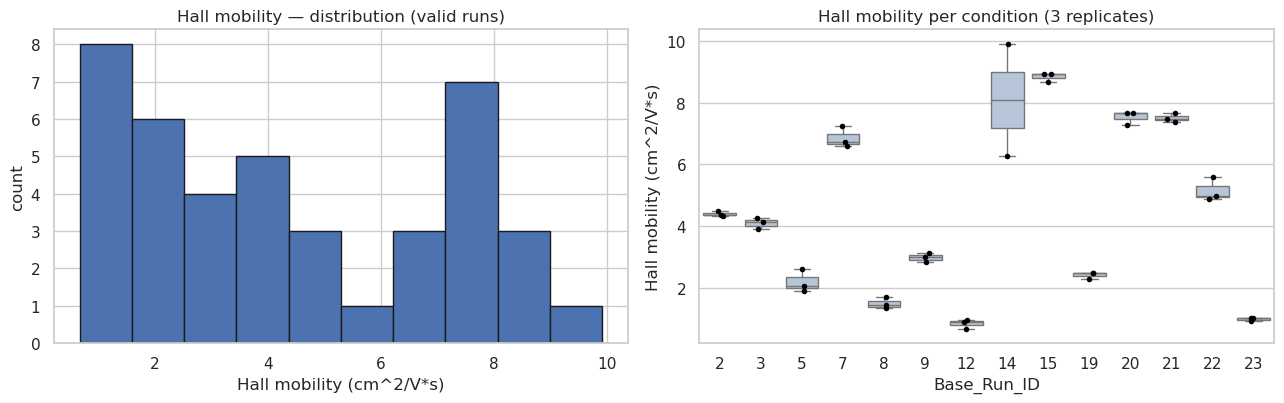

In [143]:
# Hall mobility distribution and per-condition box plot (valid measurements only).
valid = df.dropna(subset=[RESP]).copy()
print(valid[RESP].describe().round(3))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
axes[0].hist(valid[RESP], bins=10, edgecolor='k')
axes[0].set_title('Hall mobility — distribution (valid runs)')
axes[0].set_xlabel(RESP); axes[0].set_ylabel('count')

sns.boxplot(data=valid, x='Base_Run_ID', y=RESP, ax=axes[1], color='lightsteelblue')
sns.stripplot(data=valid, x='Base_Run_ID', y=RESP, ax=axes[1], color='black', size=4)
axes[1].set_title('Hall mobility per condition (3 replicates)')
plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR, 'hall_mobility_overview.png'), dpi=200); plt.show()

count    4.100000e+01
mean     1.071512e+20
std      8.407080e+19
min      1.530000e+19
25%      4.550000e+19
50%      5.660000e+19
75%      1.740000e+20
max      3.240000e+20
Name: Carrier concentration (#/cm^3), dtype: float64


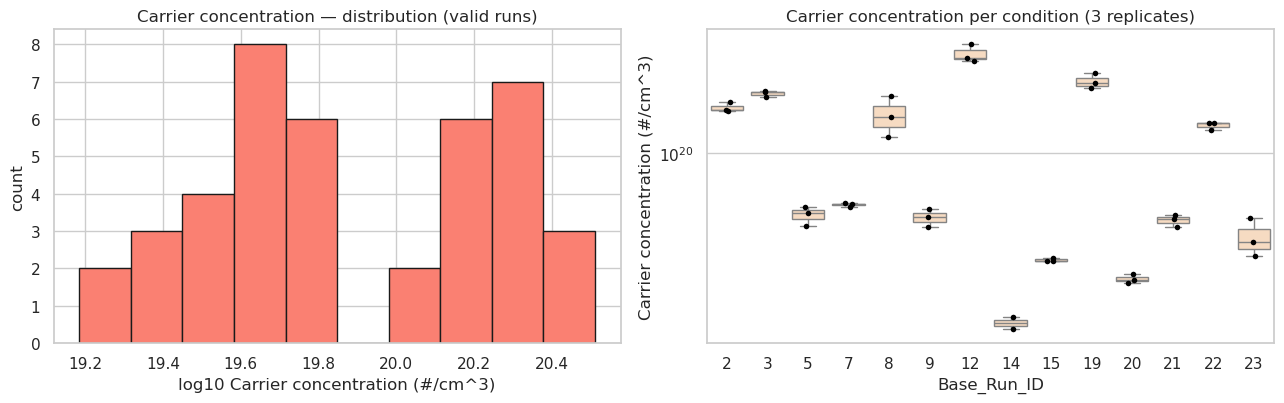

In [144]:
# Carrier concentration distribution and per-condition box plot (valid measurements only).
# Carrier spans orders of magnitude (~1e19 #/cm^3), so both panels use a log scale.
valid_carr = df.dropna(subset=[CARR]).copy()
print(valid_carr[CARR].describe().round(3))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
axes[0].hist(np.log10(valid_carr[CARR]), bins=10, edgecolor='k', color='salmon')
axes[0].set_title('Carrier concentration — distribution (valid runs)')
axes[0].set_xlabel('log10 ' + CARR); axes[0].set_ylabel('count')

sns.boxplot(data=valid_carr, x='Base_Run_ID', y=CARR, ax=axes[1], color='peachpuff')
sns.stripplot(data=valid_carr, x='Base_Run_ID', y=CARR, ax=axes[1], color='black', size=4)
axes[1].set_yscale('log')
axes[1].set_title('Carrier concentration per condition (3 replicates)')
plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR, 'carrier_concentration_overview.png'), dpi=200); plt.show()

In [145]:
# Condition-level summary table (valid runs).
summary = (valid.groupby('Base_Run_ID')
                .agg(n=('Replicate','count'),
                     mobility_mean=(RESP,'mean'),
                     mobility_std=(RESP,'std'),
                     mobility_min=(RESP,'min'),
                     mobility_max=(RESP,'max'),
                     carrier_mean=(CARR,'mean'))
                .round(3))
factor_lookup = df.drop_duplicates('Base_Run_ID').set_index('Base_Run_ID')[FACTORS]
summary = summary.join(factor_lookup)
summary.to_excel(os.path.join(OUT_DIR, 'condition_summary.xlsx'))
summary

,n,mobility_mean,mobility_std,mobility_min,mobility_max,carrier_mean,Dep Power (W),O2 Flow (sccm),Dep Press (mTorr),Dep Temp (°C),Ox Temp (°C),Ox Press (atm),Ox Time (min),Vac Ann Temp (°C),Vac Ann Time (min),Dep Thickness (nm)
Base_Run_ID,,,,,,,,,,,,,,,,
2,3,4.393,0.085,4.33,4.49,1.640000e+20,28,11.5,9.7,25,476.8,0.02,14.3,155.4,18.1,5.1
3,3,4.097,0.189,3.89,4.26,1.903333e+20,40,9.1,3.4,425,262.5,0.02,71.7,400.0,57.9,2.2
5,3,2.197,0.374,1.91,2.62,5.166667e+19,19,7.0,8.5,25,661.6,1.00,82.5,288.6,31.0,3.5
7,3,6.847,0.355,6.58,7.25,5.773333e+19,23,1.6,7.3,25,364.3,0.02,118.0,474.1,117.0,8.6
8,3,1.490,0.187,1.34,1.70,1.503333e+20,8,14.2,2.6,425,594.5,1.00,26.1,48.9,14.6,1.7
9,3,2.987,0.150,2.84,3.14,5.040000e+19,7,8.7,7.6,425,429.6,1.00,81.0,229.6,42.4,9.6
12,3,0.837,0.146,0.67,0.94,2.903333e+20,15,11.3,5.3,25,231.1,1.00,20.3,83.7,3.6,6.9
14,2,8.095,2.567,6.28,9.91,1.635000e+19,36,13.4,6.3,425,694.7,0.02,1.1,217.4,29.1,7.8
15,3,8.843,0.142,8.68,8.94,3.196667e+19,27,6.0,4.5,25,649.3,0.02,62.7,362.2,46.5,6.2


### Preliminary takeaways

_The cells above produce the numbers; the bullets below frame how to read them._
- The contact-fail rate and exactly which conditions failed are printed by the cell above. Across the full 23-condition delivery, the failures cluster at **high `Vac Ann Temp`** (every fully-failed condition annealed well above the surviving ones) — this is the signal exploited in §7 and §8.
- `factor_means_fail_vs_valid.xlsx` is the quickest place to spot which knob settings cluster with failure.
- Replicate-to-replicate scatter is small for most surviving conditions — useful for ANOVA below.
- Carrier concentration spans ~1.5e+19 to ~3e+20 cm⁻³ (over an order of magnitude), so it is modeled / plotted on a log scale throughout.

## 3. ANOVA — Hall mobility **and** carrier concentration

With 14 valid conditions × ~3 replicates (41 valid measurements) and 10 factors, a full main-effects ANOVA is rank-deficient. We do two things, **for both responses**:

1. **One-way ANOVA per factor** — each continuous factor is binned at its median into Low/High (binary factors keep their two native levels); this gives every factor an isolated F-test against the response. Carrier concentration is tested on `log10` because it spans more than an order of magnitude.
2. **Replicate (between-condition) ANOVA** — confirms that `Base_Run_ID` (condition) explains variance beyond replicate noise.

Each is saved as Excel, with the response noted in a `response` column. The carrier-concentration ANOVA is the piece that was missing from the earlier version of this notebook.

In [146]:
# One-way ANOVA per factor, for BOTH responses.
# Carrier concentration is tested on log10 (spans >1 order of magnitude).
def per_factor_anova(data, factors, resp_col, transform=None):
    sub = data.dropna(subset=[resp_col]).copy()
    y = np.log10(sub[resp_col]) if transform == 'log10' else sub[resp_col]
    out = []
    for f in factors:
        x = sub[f].values
        if len(np.unique(x)) < 2:
            out.append({'factor': f, 'levels': 'constant', 'F': np.nan, 'p_value': np.nan}); continue
        if len(np.unique(x)) == 2:
            groups = [y[sub[f] == v].values for v in np.unique(x)]; level_label = 'binary'
        else:
            med = np.median(x)
            groups = [y[sub[f] <= med].values, y[sub[f] > med].values]
            level_label = f'split @ median={med:g}'
        groups = [g for g in groups if len(g) >= 2]
        if len(groups) < 2:
            out.append({'factor': f, 'levels': level_label, 'F': np.nan, 'p_value': np.nan}); continue
        F, p = stats.f_oneway(*groups)
        out.append({'factor': f, 'levels': level_label,
                    'n_low': len(groups[0]), 'n_high': len(groups[1]),
                    'F': round(float(F), 4), 'p_value': round(float(p), 4)})
    return pd.DataFrame(out).sort_values('p_value', na_position='last')

anova_mob  = per_factor_anova(valid, FACTORS, RESP)
anova_carr = per_factor_anova(valid, FACTORS, CARR, transform='log10')
anova_mob['response']  = 'Hall mobility'
anova_carr['response'] = 'log10 Carrier concentration'

# keep the legacy single-response object/file for backward compatibility, plus a combined file
anova_df = anova_mob
with pd.ExcelWriter(os.path.join(OUT_DIR, 'anova_per_factor.xlsx')) as w:
    anova_mob.to_excel(w,  sheet_name='Hall_mobility',  index=False)
    anova_carr.to_excel(w, sheet_name='log10_carrier',  index=False)
print('Per-factor ANOVA — Hall mobility (top rows):')
print(anova_mob.head(4).to_string(index=False))
print('\nPer-factor ANOVA — log10 carrier concentration (top rows):')
print(anova_carr.head(4).to_string(index=False))
anova_carr

Per-factor ANOVA — Hall mobility (top rows):
            factor               levels  n_low  n_high       F  p_value      response
    Ox Press (atm)               binary     20      21 73.3590   0.0000 Hall mobility
     Dep Power (W)    split @ median=21     21      20  7.6843   0.0085 Hall mobility
Vac Ann Time (min)  split @ median=42.4     23      18  6.1572   0.0175 Hall mobility
      Ox Temp (°C) split @ median=476.8     21      20  4.1829   0.0476 Hall mobility

Per-factor ANOVA — log10 carrier concentration (top rows):
           factor               levels  n_low  n_high       F  p_value                    response
Dep Press (mTorr)   split @ median=6.1     21      20 16.5565   0.0002 log10 Carrier concentration
     Ox Temp (°C) split @ median=476.8     21      20  6.5277   0.0146 log10 Carrier concentration
    Dep Temp (°C)               binary     21      20  5.9997   0.0189 log10 Carrier concentration
   Ox Press (atm)               binary     20      21  5.9150   0.019

,factor,levels,n_low,n_high,F,p_value,response
2,Dep Press (mTorr),split @ median=6.1,21,20,16.5565,0.0002,log10 Carrier concentration
4,Ox Temp (°C),split @ median=476.8,21,20,6.5277,0.0146,log10 Carrier concentration
3,Dep Temp (°C),binary,21,20,5.9997,0.0189,log10 Carrier concentration
5,Ox Press (atm),binary,20,21,5.9150,0.0197,log10 Carrier concentration
1,O2 Flow (sccm),split @ median=8.7,21,20,5.8650,0.0202,log10 Carrier concentration
9,Dep Thickness (nm),split @ median=6.2,21,20,3.3022,0.0769,log10 Carrier concentration
8,Vac Ann Time (min),split @ median=42.4,23,18,2.6624,0.1108,log10 Carrier concentration
0,Dep Power (W),split @ median=21,21,20,1.3358,0.2548,log10 Carrier concentration
6,Ox Time (min),split @ median=62.7,23,18,0.6681,0.4187,log10 Carrier concentration
7,Vac Ann Temp (°C),split @ median=263.1,23,18,0.0102,0.9200,log10 Carrier concentration


In [147]:
# Between-condition ANOVA: does Base_Run_ID explain variance beyond replicate noise?
# Run for BOTH responses (carrier on log10).
def between_condition_anova(data, resp_col, transform=None):
    sub = data.dropna(subset=[resp_col]).copy()
    if transform == 'log10':
        sub['_y_'] = np.log10(sub[resp_col])
    else:
        sub['_y_'] = sub[resp_col]
    model = ols('_y_ ~ C(Base_Run_ID)', data=sub).fit()
    tbl = sm.stats.anova_lm(model, typ=2).round(4)
    return tbl, model.rsquared

anova_cond_mob,  r2_mob  = between_condition_anova(valid, RESP)
anova_cond_carr, r2_carr = between_condition_anova(valid, CARR, transform='log10')

with pd.ExcelWriter(os.path.join(OUT_DIR, 'anova_between_conditions.xlsx')) as w:
    anova_cond_mob.to_excel(w,  sheet_name='Hall_mobility')
    anova_cond_carr.to_excel(w, sheet_name='log10_carrier')

print('=== Hall mobility ~ C(Base_Run_ID) ===')
print(anova_cond_mob); print(f'R^2 = {r2_mob:.3f}\n')
print('=== log10 carrier concentration ~ C(Base_Run_ID) ===')
print(anova_cond_carr); print(f'R^2 = {r2_carr:.3f}')

=== Hall mobility ~ C(Base_Run_ID) ===
                  sum_sq    df        F  PR(>F)
C(Base_Run_ID)  295.8467  13.0  78.1394     0.0
Residual          7.8635  27.0      NaN     NaN
R^2 = 0.974

=== log10 carrier concentration ~ C(Base_Run_ID) ===
                sum_sq    df         F  PR(>F)
C(Base_Run_ID)  5.4036  13.0  206.8827     0.0
Residual        0.0542  27.0       NaN     NaN
R^2 = 0.990


## 4. Coefficient of variation across replicates

CV (%) = 100 × std / mean, computed per `Base_Run_ID` over its replicates — for **both** Hall mobility and carrier concentration. This tells us how repeatable each condition is independent of its absolute level. The output Excel `cv_percentage.xlsx` has one sheet per response plus a wide `combined` sheet for side-by-side comparison.

In [148]:
# Coefficient of variation per condition, for BOTH responses.
def cv_table(data, resp_col, label):
    rows = []
    for bid, g in data.dropna(subset=[resp_col]).groupby('Base_Run_ID'):
        m = g[resp_col].mean(); s = g[resp_col].std()
        rows.append({'Base_Run_ID': bid, 'n': len(g),
                     f'{label}_mean': m, f'{label}_std': s,
                     f'{label}_CV_%': round(100 * s / m, 2) if m else np.nan})
    return pd.DataFrame(rows)

cv_mob  = cv_table(valid, RESP, 'mobility')
cv_carr = cv_table(valid, CARR, 'carrier')
# keep the legacy `cv_df` (mobility) plus a combined wide table
cv_df = cv_mob.rename(columns={'mobility_mean': 'mean', 'mobility_std': 'std',
                               'mobility_CV_%': 'CV_%'}).sort_values('CV_%')
cv_combined = cv_mob.merge(cv_carr.drop(columns='n'), on='Base_Run_ID', how='outer').sort_values('Base_Run_ID')
for c in ['mobility_mean', 'mobility_std', 'carrier_mean', 'carrier_std']:
    if c in cv_combined:
        cv_combined[c] = cv_combined[c].map(lambda v: round(v, 3) if pd.notna(v) else v)

with pd.ExcelWriter(os.path.join(OUT_DIR, 'cv_percentage.xlsx')) as w:
    cv_mob.round(3).to_excel(w,  sheet_name='mobility', index=False)
    cv_carr.round(3).to_excel(w, sheet_name='carrier',  index=False)
    cv_combined.to_excel(w,      sheet_name='combined', index=False)

print(f'Mobility CV  — median {cv_mob["mobility_CV_%"].median():.2f}% | max {cv_mob["mobility_CV_%"].max():.2f}%')
print(f'Carrier  CV  — median {cv_carr["carrier_CV_%"].median():.2f}% | max {cv_carr["carrier_CV_%"].max():.2f}%')
cv_combined

Mobility CV  — median 5.11% | max 31.71%
Carrier  CV  — median 7.25% | max 22.04%


,Base_Run_ID,n,mobility_mean,mobility_std,mobility_CV_%,carrier_mean,carrier_std,carrier_CV_%
0,2,3,4.393,0.085,1.94,1.640000e+20,8.717798e+18,5.32
1,3,3,4.097,0.189,4.61,1.903333e+20,6.658328e+18,3.50
2,5,3,2.197,0.374,17.04,5.166667e+19,5.161718e+18,9.99
3,7,3,6.847,0.355,5.19,5.773333e+19,1.001665e+18,1.73
4,8,3,1.490,0.187,12.57,1.503333e+20,3.312602e+19,22.04
5,9,3,2.987,0.150,5.03,5.040000e+19,4.803124e+18,9.53
6,12,3,0.837,0.146,17.42,2.903333e+20,2.967041e+19,10.22
7,14,2,8.095,2.567,31.71,1.635000e+19,1.484924e+18,9.08
8,15,3,8.843,0.142,1.61,3.196667e+19,5.507571e+17,1.72
9,19,3,2.413,0.116,4.80,2.163333e+20,1.789786e+19,8.27


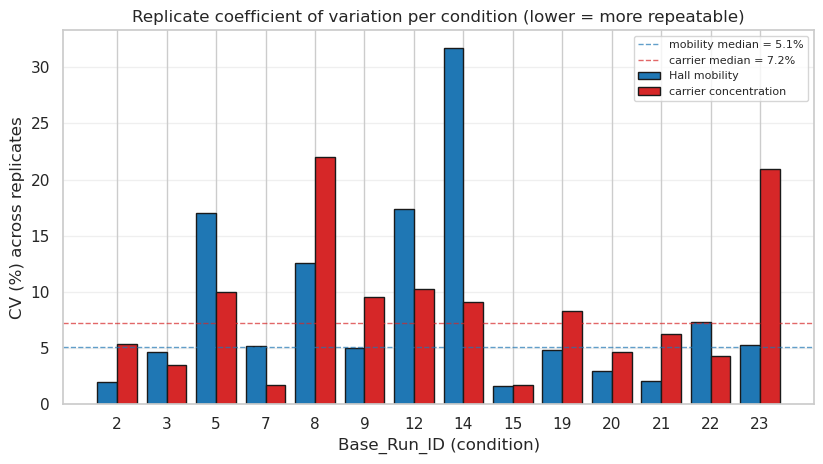

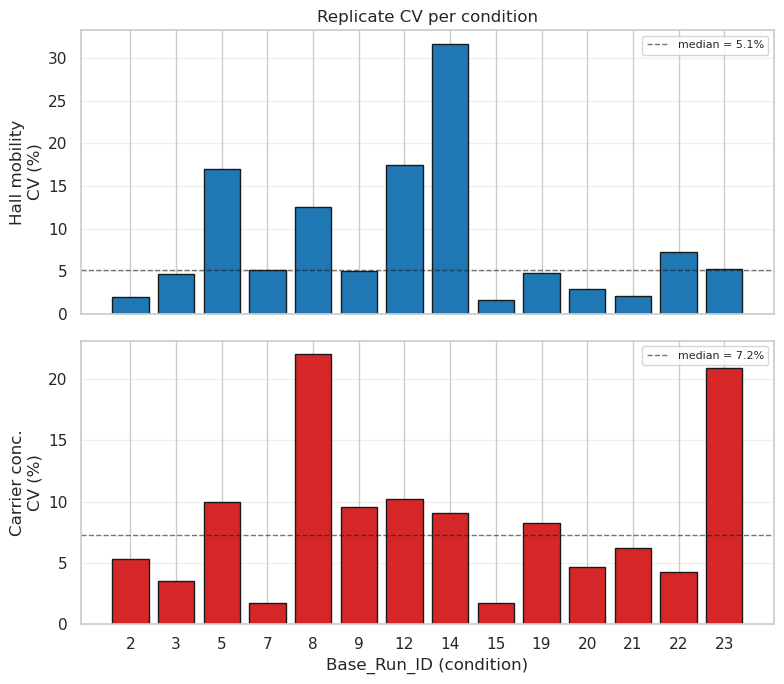

In [149]:
# --- Bar plots: coefficient of variation per condition (mobility & carrier) ---
cvp = cv_combined.sort_values('Base_Run_ID')
ids = cvp['Base_Run_ID'].astype(int).astype(str).values
x = np.arange(len(ids))
mob_med, carr_med = cvp['mobility_CV_%'].median(), cvp['carrier_CV_%'].median()

# Version 1 — single plot, grouped bars (both responses on shared axes).
w = 0.4
fig, ax = plt.subplots(figsize=(max(8, 0.6 * len(ids)), 4.8))
ax.bar(x - w/2, cvp['mobility_CV_%'], width=w, label='Hall mobility', color='#1f77b4', edgecolor='k')
ax.bar(x + w/2, cvp['carrier_CV_%'], width=w, label='carrier concentration', color='#d62728', edgecolor='k')
ax.axhline(mob_med,  ls='--', color='#1f77b4', alpha=0.7, lw=1, label=f'mobility median = {mob_med:.1f}%')
ax.axhline(carr_med, ls='--', color='#d62728', alpha=0.7, lw=1, label=f'carrier median = {carr_med:.1f}%')
ax.set_xticks(x); ax.set_xticklabels(ids)
ax.set_xlabel('Base_Run_ID (condition)'); ax.set_ylabel('CV (%) across replicates')
ax.set_title('Replicate coefficient of variation per condition (lower = more repeatable)')
ax.legend(fontsize=8); ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'cv_barplot.png'), dpi=200)
plt.show()

# Version 2 — two stacked panels sharing the same x-axis.
fig, axes = plt.subplots(2, 1, figsize=(max(8, 0.55 * len(ids)), 7), sharex=True)
axes[0].bar(x, cvp['mobility_CV_%'], color='#1f77b4', edgecolor='k')
axes[0].axhline(mob_med, ls='--', color='k', alpha=0.6, lw=1, label=f'median = {mob_med:.1f}%')
axes[0].set_ylabel('Hall mobility\nCV (%)'); axes[0].set_title('Replicate CV per condition'); axes[0].legend(fontsize=8)
axes[0].grid(True, axis='y', alpha=0.3)
axes[1].bar(x, cvp['carrier_CV_%'], color='#d62728', edgecolor='k')
axes[1].axhline(carr_med, ls='--', color='k', alpha=0.6, lw=1, label=f'median = {carr_med:.1f}%')
axes[1].set_ylabel('Carrier conc.\nCV (%)'); axes[1].set_xlabel('Base_Run_ID (condition)'); axes[1].legend(fontsize=8)
axes[1].grid(True, axis='y', alpha=0.3)
axes[1].set_xticks(x); axes[1].set_xticklabels(ids)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'cv_barplot_2panel.png'), dpi=200)
plt.show()

### 4.1  Consolidated 23-condition table (means + CV)

Collapse the 3 replicates of each base run into a single row, giving the **23 unique experiments** with their factor settings, mean Hall mobility, mean carrier concentration, and the replicate **coefficient of variation (CV %)** for both responses. Conditions whose replicates all failed (Contact Fail) carry no valid measurement and appear as `NaN`. Saved to `condition_consolidated.xlsx`.

In [150]:
# --- Consolidated per-condition table: factor settings + mean responses + replicate CV ---
# One row per unique experiment (Base_Run_ID); the 3 replicates are collapsed into mean/std/CV.
def _agg_response(data, col):
    """Per-condition n / mean / std / CV% for a single response column (valid rows only)."""
    g = data.dropna(subset=[col]).groupby('Base_Run_ID')[col]
    out = g.agg(n='count', mean='mean', std='std')
    out['CV_%'] = (100 * out['std'] / out['mean']).round(2)
    return out

# Factor settings are identical across replicates -> one row per condition.
factor_lookup = df.drop_duplicates('Base_Run_ID').set_index('Base_Run_ID')[FACTORS]

mob  = _agg_response(valid, RESP)   # Hall mobility
carr = _agg_response(valid, CARR)   # Carrier concentration

consolidated = factor_lookup.copy()
consolidated['n_valid']       = mob['n']                 # valid replicates per condition
consolidated['mobility_mean'] = mob['mean'].round(3)
consolidated['mobility_std']  = mob['std'].round(3)
consolidated['mobility_CV_%'] = mob['CV_%']
consolidated['carrier_mean']  = carr['mean']
consolidated['carrier_std']   = carr['std']
consolidated['carrier_CV_%']  = carr['CV_%']
consolidated.index.name = 'Base_Run_ID'
consolidated = consolidated.sort_index()

consolidated.to_excel(os.path.join(OUT_DIR, 'condition_consolidated.xlsx'))
print(f'Consolidated table: {consolidated.shape[0]} unique conditions x {consolidated.shape[1]} columns')
_failed = sorted(consolidated.index[consolidated['n_valid'].isna()].tolist())
print('Conditions with no valid measurement (Contact Fail):', _failed if _failed else 'none')
print(OUT_DIR)
consolidated

Consolidated table: 23 unique conditions x 17 columns
Conditions with no valid measurement (Contact Fail): [1, 4, 6, 10, 11, 13, 16, 17, 18]
output/experiment02_update_all_sobol


,Dep Power (W),O2 Flow (sccm),Dep Press (mTorr),Dep Temp (°C),Ox Temp (°C),Ox Press (atm),Ox Time (min),Vac Ann Temp (°C),Vac Ann Time (min),Dep Thickness (nm),n_valid,mobility_mean,mobility_std,mobility_CV_%,carrier_mean,carrier_std,carrier_CV_%
Base_Run_ID,,,,,,,,,,,,,,,,,
1,3,4.4,4.3,425,557.0,1.00,98.8,584.1,90.1,7.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,28,11.5,9.7,25,476.8,0.02,14.3,155.4,18.1,5.1,3.0,4.393,0.085,1.94,1.640000e+20,8.717798e+18,5.32
3,40,9.1,3.4,425,262.5,0.02,71.7,400.0,57.9,2.2,3.0,4.097,0.189,4.61,1.903333e+20,6.658328e+18,3.50
4,14,16.9,6.6,25,774.1,1.00,39.9,728.4,73.6,9.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,19,7.0,8.5,25,661.6,1.00,82.5,288.6,31.0,3.5,3.0,2.197,0.374,17.04,5.166667e+19,5.161718e+18,9.99
6,34,19.1,5.6,425,300.0,0.02,58.2,620.4,77.2,5.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,23,1.6,7.3,25,364.3,0.02,118.0,474.1,117.0,8.6,3.0,6.847,0.355,5.19,5.773333e+19,1.001665e+18,1.73
8,8,14.2,2.6,425,594.5,1.00,26.1,48.9,14.6,1.7,3.0,1.490,0.187,12.57,1.503333e+20,3.312602e+19,22.04
9,7,8.7,7.6,425,429.6,1.00,81.0,229.6,42.4,9.6,3.0,2.987,0.150,5.03,5.040000e+19,4.803124e+18,9.53


## 5. Linear regression validation

**Caveat (important).** With ~41 valid measurements (14 unique conditions) and 10 process factors, a full linear model is still over-parameterised, and replicates within a condition do not give the regression independent information about the factors. We do two cross-validations:

1. **LOO-CV at the condition level** on a condition-mean dataset (n=14) using the most informative factors. Honest, still a small sample.
2. **Leave-one-condition-out (LOGO)** on the full replicate-level dataset — each fold leaves out an entire condition (all its replicates) so the test set is not contaminated.

Both are persisted with metrics and predicted-vs-actual values. The number of factors `k` and the sample sizes are printed by the cells (they adapt to whatever valid data is present).

In [151]:
# Build condition-level dataset (6 rows).
cond_df = valid.groupby('Base_Run_ID').agg({**{f:'first' for f in FACTORS}, RESP:'mean'}).reset_index()
print('Condition-level dataset:', cond_df.shape)
X_full = cond_df[FACTORS].values
y_full = cond_df[RESP].values

# Pick the top-k factors by |Pearson r| with mobility (k chosen so n - k - 1 >= 1).
ranks = []
for f in FACTORS:
    if cond_df[f].nunique() < 2:
        ranks.append((f, 0.0)); continue
    r, _ = stats.pearsonr(cond_df[f], cond_df[RESP])
    ranks.append((f, abs(r)))
ranks = sorted(ranks, key=lambda t: -t[1])
k = min(3, len(cond_df) - 2)
top_factors = [f for f, _ in ranks[:k]]
print(f'Top-{k} factors by |corr| with mobility: {top_factors}')

Xc = cond_df[top_factors].values
yc = cond_df[RESP].values
scaler = StandardScaler().fit(Xc)
Xc_s = scaler.transform(Xc)

# LOO on the 6 conditions.
loo = LeaveOneOut()
preds = np.zeros_like(yc); actuals = yc.copy()
for tr, te in loo.split(Xc_s):
    m = LinearRegression().fit(Xc_s[tr], yc[tr])
    preds[te] = m.predict(Xc_s[te])
loo_r2  = r2_score(actuals, preds)
loo_rmse = np.sqrt(mean_squared_error(actuals, preds))
loo_mae = float(np.mean(np.abs(actuals - preds)))

# Fit on all 6 to report training R^2 too.
m_full = LinearRegression().fit(Xc_s, yc)
train_r2 = m_full.score(Xc_s, yc)

loo_pred_df = pd.DataFrame({'Base_Run_ID': cond_df['Base_Run_ID'],
                            'actual_mobility': actuals,
                            'loo_predicted': preds.round(3),
                            'residual': (actuals - preds).round(3)})
print(f'LOO  R²: {loo_r2:.3f}  |  RMSE: {loo_rmse:.3f}  |  MAE: {loo_mae:.3f}')
print(f'Train R² (n={len(yc)}, k={k}): {train_r2:.3f}')
loo_pred_df

Condition-level dataset: (14, 12)
Top-3 factors by |corr| with mobility: ['Ox Press (atm)', 'Ox Temp (°C)', 'Vac Ann Time (min)']
LOO  R²: 0.685  |  RMSE: 1.521  |  MAE: 1.396
Train R² (n=14, k=3): 0.847


,Base_Run_ID,actual_mobility,loo_predicted,residual
0,2,4.393333,5.973,-1.580
1,3,4.096667,5.520,-1.424
2,5,2.196667,4.451,-2.255
3,7,6.846667,7.346,-0.499
4,8,1.490000,3.258,-1.768
5,9,2.986667,2.226,0.761
6,12,0.836667,-0.786,1.623
7,14,8.095000,7.141,0.954
8,15,8.843333,7.141,1.702
9,19,2.413333,1.819,0.595


In [152]:
# Group K-fold (leave-one-condition-out) on the full 18-row dataset using the same top-k factors.
from sklearn.model_selection import LeaveOneGroupOut
X_rep = valid[top_factors].values
y_rep = valid[RESP].values
groups = valid['Base_Run_ID'].values
scaler2 = StandardScaler().fit(X_rep)
X_rep_s = scaler2.transform(X_rep)

logo = LeaveOneGroupOut()
preds_g = np.zeros_like(y_rep, dtype=float)
for tr, te in logo.split(X_rep_s, y_rep, groups):
    m = LinearRegression().fit(X_rep_s[tr], y_rep[tr])
    preds_g[te] = m.predict(X_rep_s[te])
logo_r2 = r2_score(y_rep, preds_g)
logo_rmse = np.sqrt(mean_squared_error(y_rep, preds_g))
logo_mae = float(np.mean(np.abs(y_rep - preds_g)))
print(f'LOGO R²: {logo_r2:.3f}  |  RMSE: {logo_rmse:.3f}  |  MAE: {logo_mae:.3f}')

logo_pred_df = valid[['Base_Run_ID','Replicate', RESP]].copy()
logo_pred_df['logo_predicted'] = preds_g.round(3)
logo_pred_df['residual'] = (logo_pred_df[RESP] - logo_pred_df['logo_predicted']).round(3)
logo_pred_df

LOGO R²: 0.655  |  RMSE: 1.598  |  MAE: 1.456


,Base_Run_ID,Replicate,Hall mobility (cm^2/V*s),logo_predicted,residual
3,2,1,4.36,5.938,-1.578
4,2,2,4.33,5.938,-1.608
5,2,3,4.49,5.938,-1.448
6,3,1,3.89,5.519,-1.629
7,3,2,4.14,5.519,-1.379
8,3,3,4.26,5.519,-1.259
12,5,1,1.91,4.423,-2.513
13,5,2,2.62,4.423,-1.803
14,5,3,2.06,4.423,-2.363
18,7,1,7.25,7.343,-0.093


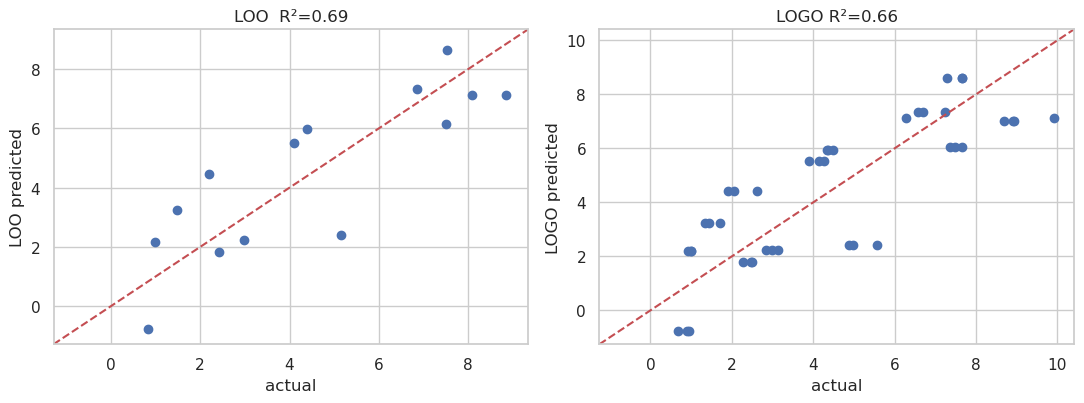

,scheme,R2,RMSE,MAE
0,"Train (condition means, n=14)",0.847,NaN,NaN
1,"LOO (condition means, n=14)",0.685,1.521,1.396
2,"LOGO (replicate-level, n=41)",0.655,1.598,1.456


In [153]:
# Save consolidated regression validation Excel.
metrics = pd.DataFrame([
    {'scheme': f'Train (condition means, n={len(yc)})', 'R2': round(train_r2,3), 'RMSE': np.nan, 'MAE': np.nan},
    {'scheme': f'LOO  (condition means, n={len(yc)})', 'R2': round(loo_r2,3), 'RMSE': round(loo_rmse,3), 'MAE': round(loo_mae,3)},
    {'scheme': f'LOGO (replicate-level, n={len(y_rep)})', 'R2': round(logo_r2,3), 'RMSE': round(logo_rmse,3), 'MAE': round(logo_mae,3)},
])
coefs = pd.DataFrame({'factor': top_factors,
                      'coef_standardized': m_full.coef_.round(4)})
coefs.loc[len(coefs)] = ['intercept', round(float(m_full.intercept_), 4)]

with pd.ExcelWriter(os.path.join(OUT_DIR, 'linear_regression_validation.xlsx')) as w:
    metrics.to_excel(w, sheet_name='metrics', index=False)
    coefs.to_excel(w, sheet_name='coefficients', index=False)
    loo_pred_df.to_excel(w, sheet_name='LOO_predictions', index=False)
    logo_pred_df.to_excel(w, sheet_name='LOGO_predictions', index=False)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].scatter(actuals, preds); lim = [min(actuals.min(), preds.min())-0.5, max(actuals.max(), preds.max())+0.5]
axes[0].plot(lim, lim, 'r--'); axes[0].set_xlim(lim); axes[0].set_ylim(lim)
axes[0].set_xlabel('actual'); axes[0].set_ylabel('LOO predicted'); axes[0].set_title(f'LOO  R²={loo_r2:.2f}')
axes[1].scatter(y_rep, preds_g); lim = [min(y_rep.min(), preds_g.min())-0.5, max(y_rep.max(), preds_g.max())+0.5]
axes[1].plot(lim, lim, 'r--'); axes[1].set_xlim(lim); axes[1].set_ylim(lim)
axes[1].set_xlabel('actual'); axes[1].set_ylabel('LOGO predicted'); axes[1].set_title(f'LOGO R²={logo_r2:.2f}')
plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR, 'regression_pred_vs_actual.png'), dpi=200); plt.show()
metrics

### 5.1  Same validation for carrier concentration (log10)

The cross-validation above only covered Hall mobility. Here we repeat the identical scheme for **carrier concentration**, modeled in `log10` (it spans more than a decade, so a linear fit on raw counts would be dominated by the largest values):

1. **LOO-CV** on the condition-mean dataset (top-k factors by |Pearson r| with log10 carrier).
2. **Leave-one-condition-out (LOGO)** on the full replicate-level dataset.

Metrics are in `log10(#/cm^3)` units, i.e. RMSE/MAE are in **dex** (orders of magnitude). Saved to `linear_regression_validation_carrier.xlsx`.

Condition-level carrier dataset: (14, 12)
Top-3 factors by |corr| with log10 carrier: ['Dep Thickness (nm)', 'Ox Temp (°C)', 'Dep Press (mTorr)']
LOO  R2: 0.444 | RMSE: 0.278 dex | MAE: 0.219 dex
LOGO R2: 0.394 | RMSE: 0.284 dex | MAE: 0.223 dex
Train R2 (n=14, k=3): 0.772


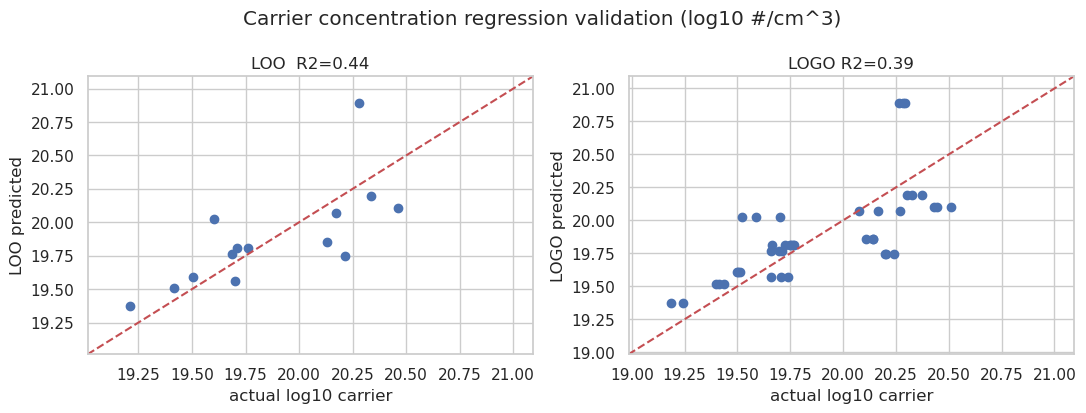

,scheme,R2,RMSE_dex,MAE_dex
0,"Train (condition means, n=14)",0.772,NaN,NaN
1,"LOO (condition means, n=14)",0.444,0.278,0.219
2,"LOGO (replicate-level, n=41)",0.394,0.284,0.223


In [154]:
# --- LOO / LOGO validation for CARRIER CONCENTRATION (modeled in log10) ---
from sklearn.model_selection import LeaveOneGroupOut

carr_valid = valid.dropna(subset=[CARR]).copy()
carr_valid['log10_carrier'] = np.log10(carr_valid[CARR])

# Condition-level means (one row per valid condition).
cond_c = (carr_valid.groupby('Base_Run_ID')
                    .agg({**{f: 'first' for f in FACTORS}, 'log10_carrier': 'mean'})
                    .reset_index())
print('Condition-level carrier dataset:', cond_c.shape)

# Rank factors by |Pearson r| with log10 carrier; keep enough that n - k - 1 >= 1.
ranks_c = []
for f in FACTORS:
    if cond_c[f].nunique() < 2:
        ranks_c.append((f, 0.0)); continue
    r, _ = stats.pearsonr(cond_c[f], cond_c['log10_carrier'])
    ranks_c.append((f, abs(r)))
ranks_c = sorted(ranks_c, key=lambda t: -t[1])
k_c = min(3, len(cond_c) - 2)
top_factors_c = [f for f, _ in ranks_c[:k_c]]
print(f'Top-{k_c} factors by |corr| with log10 carrier: {top_factors_c}')

# --- LOO on the condition means ---
Xc = cond_c[top_factors_c].values
yc_c = cond_c['log10_carrier'].values
scaler_c = StandardScaler().fit(Xc); Xc_s = scaler_c.transform(Xc)
preds_c = np.zeros_like(yc_c)
for tr, te in LeaveOneOut().split(Xc_s):
    preds_c[te] = LinearRegression().fit(Xc_s[tr], yc_c[tr]).predict(Xc_s[te])
loo_r2_c   = r2_score(yc_c, preds_c)
loo_rmse_c = np.sqrt(mean_squared_error(yc_c, preds_c))
loo_mae_c  = float(np.mean(np.abs(yc_c - preds_c)))
m_full_c   = LinearRegression().fit(Xc_s, yc_c)
train_r2_c = m_full_c.score(Xc_s, yc_c)

loo_pred_c = pd.DataFrame({'Base_Run_ID': cond_c['Base_Run_ID'],
                           'actual_log10_carrier': yc_c.round(3),
                           'loo_predicted': preds_c.round(3),
                           'residual': (yc_c - preds_c).round(3)})

# --- LOGO (leave-one-condition-out) on the replicate-level data ---
Xr = carr_valid[top_factors_c].values
yr_c = carr_valid['log10_carrier'].values
gr = carr_valid['Base_Run_ID'].values
scaler_c2 = StandardScaler().fit(Xr); Xr_s = scaler_c2.transform(Xr)
preds_gc = np.zeros_like(yr_c, dtype=float)
for tr, te in LeaveOneGroupOut().split(Xr_s, yr_c, gr):
    preds_gc[te] = LinearRegression().fit(Xr_s[tr], yr_c[tr]).predict(Xr_s[te])
logo_r2_c   = r2_score(yr_c, preds_gc)
logo_rmse_c = np.sqrt(mean_squared_error(yr_c, preds_gc))
logo_mae_c  = float(np.mean(np.abs(yr_c - preds_gc)))

logo_pred_c = carr_valid[['Base_Run_ID', 'Replicate', 'log10_carrier']].copy()
logo_pred_c['logo_predicted'] = preds_gc.round(3)
logo_pred_c['residual'] = (logo_pred_c['log10_carrier'] - logo_pred_c['logo_predicted']).round(3)

print(f'LOO  R2: {loo_r2_c:.3f} | RMSE: {loo_rmse_c:.3f} dex | MAE: {loo_mae_c:.3f} dex')
print(f'LOGO R2: {logo_r2_c:.3f} | RMSE: {logo_rmse_c:.3f} dex | MAE: {logo_mae_c:.3f} dex')
print(f'Train R2 (n={len(yc_c)}, k={k_c}): {train_r2_c:.3f}')

# --- Save consolidated Excel (carrier) ---
metrics_c = pd.DataFrame([
    {'scheme': f'Train (condition means, n={len(yc_c)})', 'R2': round(train_r2_c, 3), 'RMSE_dex': np.nan, 'MAE_dex': np.nan},
    {'scheme': f'LOO  (condition means, n={len(yc_c)})', 'R2': round(loo_r2_c, 3), 'RMSE_dex': round(loo_rmse_c, 3), 'MAE_dex': round(loo_mae_c, 3)},
    {'scheme': f'LOGO (replicate-level, n={len(yr_c)})', 'R2': round(logo_r2_c, 3), 'RMSE_dex': round(logo_rmse_c, 3), 'MAE_dex': round(logo_mae_c, 3)},
])
coefs_c = pd.DataFrame({'factor': top_factors_c, 'coef_standardized': m_full_c.coef_.round(4)})
coefs_c.loc[len(coefs_c)] = ['intercept', round(float(m_full_c.intercept_), 4)]
with pd.ExcelWriter(os.path.join(OUT_DIR, 'linear_regression_validation_carrier.xlsx')) as w:
    metrics_c.to_excel(w, sheet_name='metrics', index=False)
    coefs_c.to_excel(w, sheet_name='coefficients', index=False)
    loo_pred_c.to_excel(w, sheet_name='LOO_predictions', index=False)
    logo_pred_c.to_excel(w, sheet_name='LOGO_predictions', index=False)

# --- Predicted vs actual (log10 carrier) ---
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].scatter(yc_c, preds_c); lim = [min(yc_c.min(), preds_c.min()) - 0.2, max(yc_c.max(), preds_c.max()) + 0.2]
axes[0].plot(lim, lim, 'r--'); axes[0].set_xlim(lim); axes[0].set_ylim(lim)
axes[0].set_xlabel('actual log10 carrier'); axes[0].set_ylabel('LOO predicted'); axes[0].set_title(f'LOO  R2={loo_r2_c:.2f}')
axes[1].scatter(yr_c, preds_gc); lim = [min(yr_c.min(), preds_gc.min()) - 0.2, max(yr_c.max(), preds_gc.max()) + 0.2]
axes[1].plot(lim, lim, 'r--'); axes[1].set_xlim(lim); axes[1].set_ylim(lim)
axes[1].set_xlabel('actual log10 carrier'); axes[1].set_ylabel('LOGO predicted'); axes[1].set_title(f'LOGO R2={logo_r2_c:.2f}')
fig.suptitle('Carrier concentration regression validation (log10 #/cm^3)')
plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR, 'regression_pred_vs_actual_carrier.png'), dpi=200); plt.show()
metrics_c

### Reading the regression results
- A negative LOO R² means the model does worse than predicting the mean. Even with 14 conditions, a linear model over 10 process factors is data-starved — this is the honest signal that a simple linear surface is not yet predictive.
- LOGO uses replicates only to stabilise the slope on training folds; the test fold is always an unseen condition, so LOGO R² is the more meaningful number for predictive use.
- The standardized coefficients in `coefficients` show direction-of-effect for the top-k factors but should not be over-interpreted at this sample size.
- The same scheme is run for **both responses**: Hall mobility (cell above) and carrier concentration in log10 (§5.1). Carrier metrics are in **dex** (log10 units); compare its LOGO R² against mobility's to see which response the current factors explain better.
- All numbers above were generated from the full 69 received rows (23 conditions, 14 surviving). The §8 Bayesian optimization uses a Gaussian-process surrogate instead of a linear fit, which is far better suited to this small, nonlinear, high-dimensional regime.

## 6. Factor effects on Hall mobility and carrier concentration

Two complementary views:

1. **Pair plot (factor × response)** — every factor against both responses, with replicate points coloured by `Base_Run_ID`. This keeps the whole picture in one figure but stays readable because we do *not* draw factor-vs-factor panels.
2. **Per-factor effects grid** — one small panel per factor, two rows (mobility, carrier concentration), with the condition mean ± replicate std overlaid on the raw points and a fitted trend (linear for continuous factors, group means for binary factors). Easiest to scan visually.

Both use the valid (non-contact-fail) measurements — 14 conditions, ~41 replicate rows. Carrier concentration is plotted on a log axis because it spans more than an order of magnitude.

In [155]:
# Build the tidy frame the plots need.
plot_df = valid.copy()
# Categorical labels for the binary factors (nicer axes than 25/425 or 0.02/1.00).
plot_df['Dep Temp (°C)_lbl']  = plot_df['Dep Temp (°C)'].map({25.0:'25', 425.0:'425'}).fillna(plot_df['Dep Temp (°C)'].astype(str))
plot_df['Ox Press (atm)_lbl'] = plot_df['Ox Press (atm)'].map({0.02:'0.02', 1.00:'1.00'}).fillna(plot_df['Ox Press (atm)'].astype(str))

CONT_FACTORS = [f for f in FACTORS if not isinstance(PDO_CONFIG[f], list)]
CAT_FACTORS  = [f for f in FACTORS if     isinstance(PDO_CONFIG[f], list)]
RESPONSES = [(RESP, 'Hall mobility (cm²/V·s)', False),
             (CARR, 'Carrier concentration (#/cm³)', True)]
print(f'{len(CONT_FACTORS)} continuous factors + {len(CAT_FACTORS)} categorical factors')
print('Continuous:', CONT_FACTORS)
print('Categorical:', CAT_FACTORS)


8 continuous factors + 2 categorical factors
Continuous: ['Dep Power (W)', 'O2 Flow (sccm)', 'Dep Press (mTorr)', 'Ox Temp (°C)', 'Ox Time (min)', 'Vac Ann Temp (°C)', 'Vac Ann Time (min)', 'Dep Thickness (nm)']
Categorical: ['Dep Temp (°C)', 'Ox Press (atm)']


### 6.1  Pair plot — factors vs responses (no factor-vs-factor panels)

This is a `factor × response` grid: rows = the 10 process factors, columns = the 2 responses. Replicate points are coloured by condition (`Base_Run_ID`) so you can see how the 3 replicates of each condition cluster. Carrier concentration uses a log y-axis.

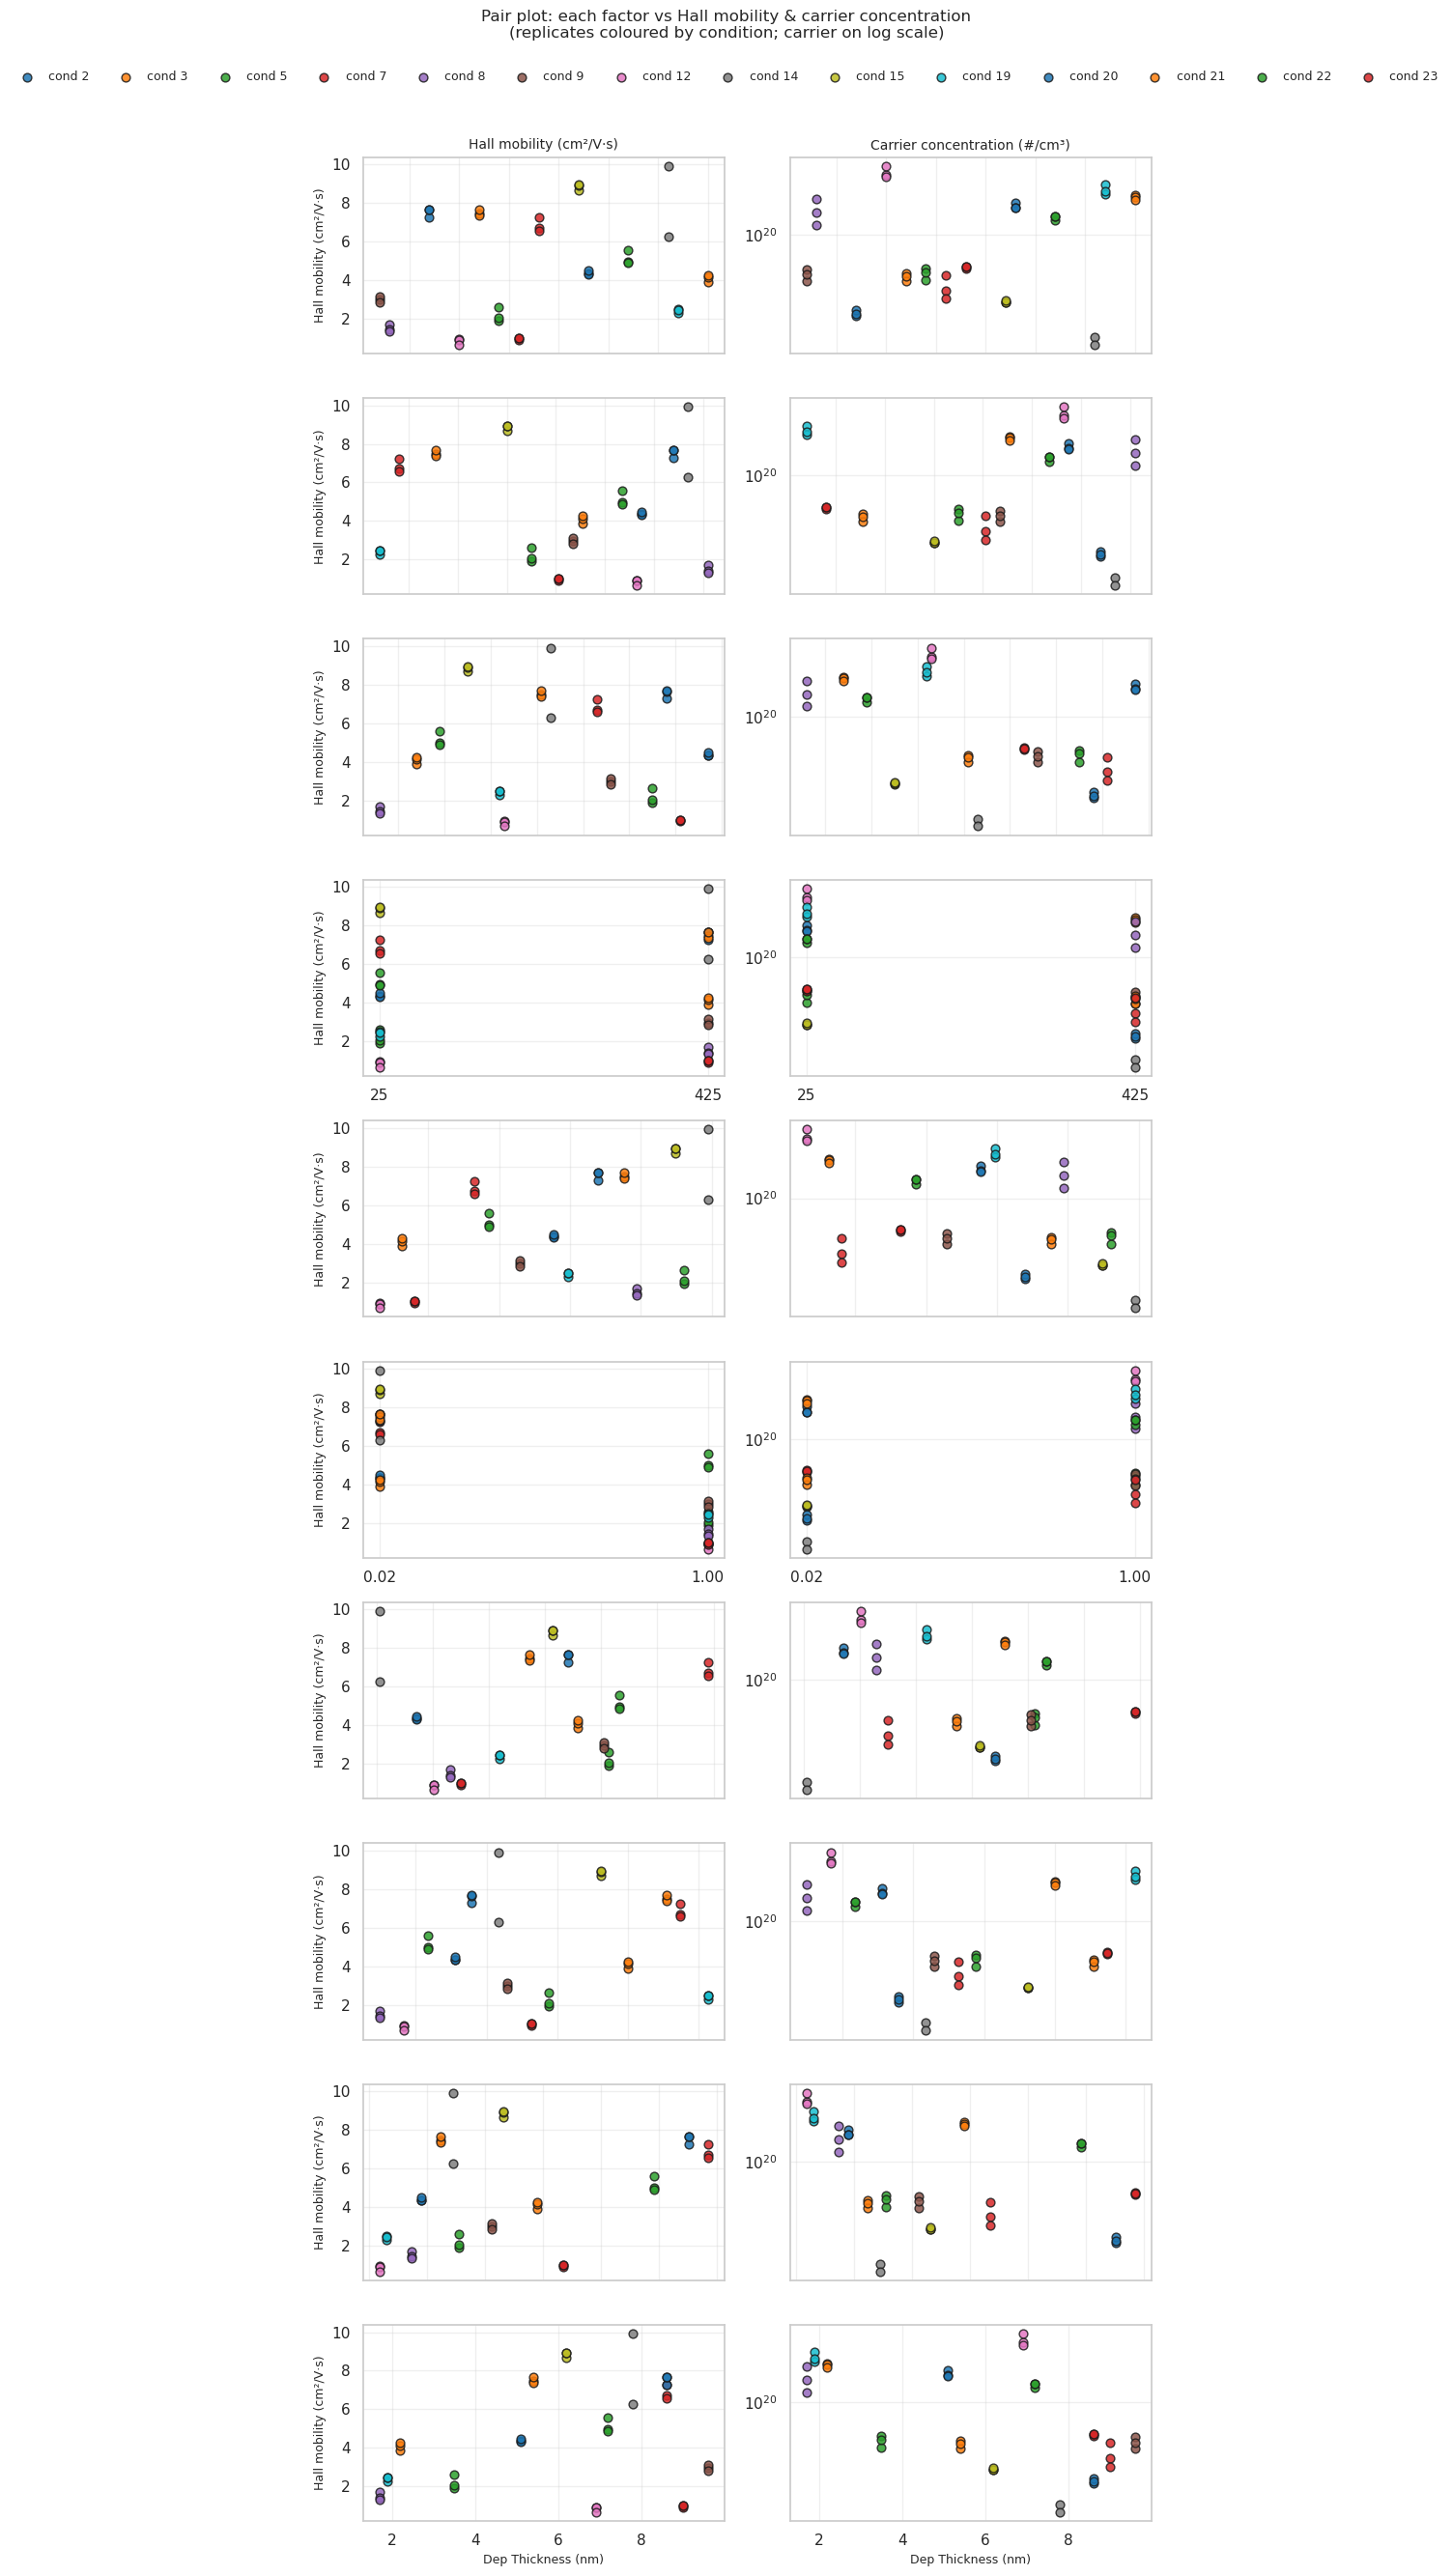

In [156]:
# 10 factors × 2 responses, replicates coloured by condition.
n_rows, n_cols = len(FACTORS), len(RESPONSES)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.6 * n_cols, 2.6 * n_rows), sharey=False)
palette = sns.color_palette('tab10', n_colors=plot_df['Base_Run_ID'].nunique())
cond_to_color = dict(zip(sorted(plot_df['Base_Run_ID'].unique()), palette))

for i, f in enumerate(FACTORS):
    is_cat = isinstance(PDO_CONFIG[f], list)
    xcol = f + '_lbl' if is_cat else f
    for j, (resp_col, resp_label, log_y) in enumerate(RESPONSES):
        ax = axes[i, j]
        sub = plot_df.dropna(subset=[resp_col])
        for cid, g in sub.groupby('Base_Run_ID'):
            ax.scatter(g[xcol], g[resp_col], color=cond_to_color[cid],
                       edgecolor='k', s=40, alpha=0.85, label=f'cond {cid}' if (i == 0 and j == 0) else None)
        if log_y:
            ax.set_yscale('log')
        if i == n_rows - 1:
            ax.set_xlabel(f, fontsize=9)
        else:
            ax.set_xlabel('')
            if not is_cat:
                ax.tick_params(axis='x', labelbottom=False)
        if j == 0:
            ax.set_ylabel(resp_label, fontsize=9)
        if i == 0:
            ax.set_title(resp_label, fontsize=10)
        ax.grid(True, alpha=0.3)

# Single legend at the top.
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=len(handles), bbox_to_anchor=(0.5, 1.005), fontsize=9, frameon=False)
fig.suptitle('Pair plot: each factor vs Hall mobility & carrier concentration\n(replicates coloured by condition; carrier on log scale)', y=1.025, fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'pairplot_factor_vs_response.png'), dpi=200, bbox_inches='tight')
plt.show()


### 6.2  Per-factor effects grid — easiest to read

One panel per factor, two rows of panels (top = mobility, bottom = carrier concentration). Each panel shows:

- **Grey dots** — individual replicates.
- **Black markers** — condition means with ±1 SD error bars across the 3 replicates.
- **Red dashed line** — best-fit linear trend for continuous factors (purely descriptive at n=6 conditions); for binary factors, a horizontal segment per level.

Because every panel has its own x-axis, you read each factor's effect in isolation — no factor-vs-factor coupling shown.

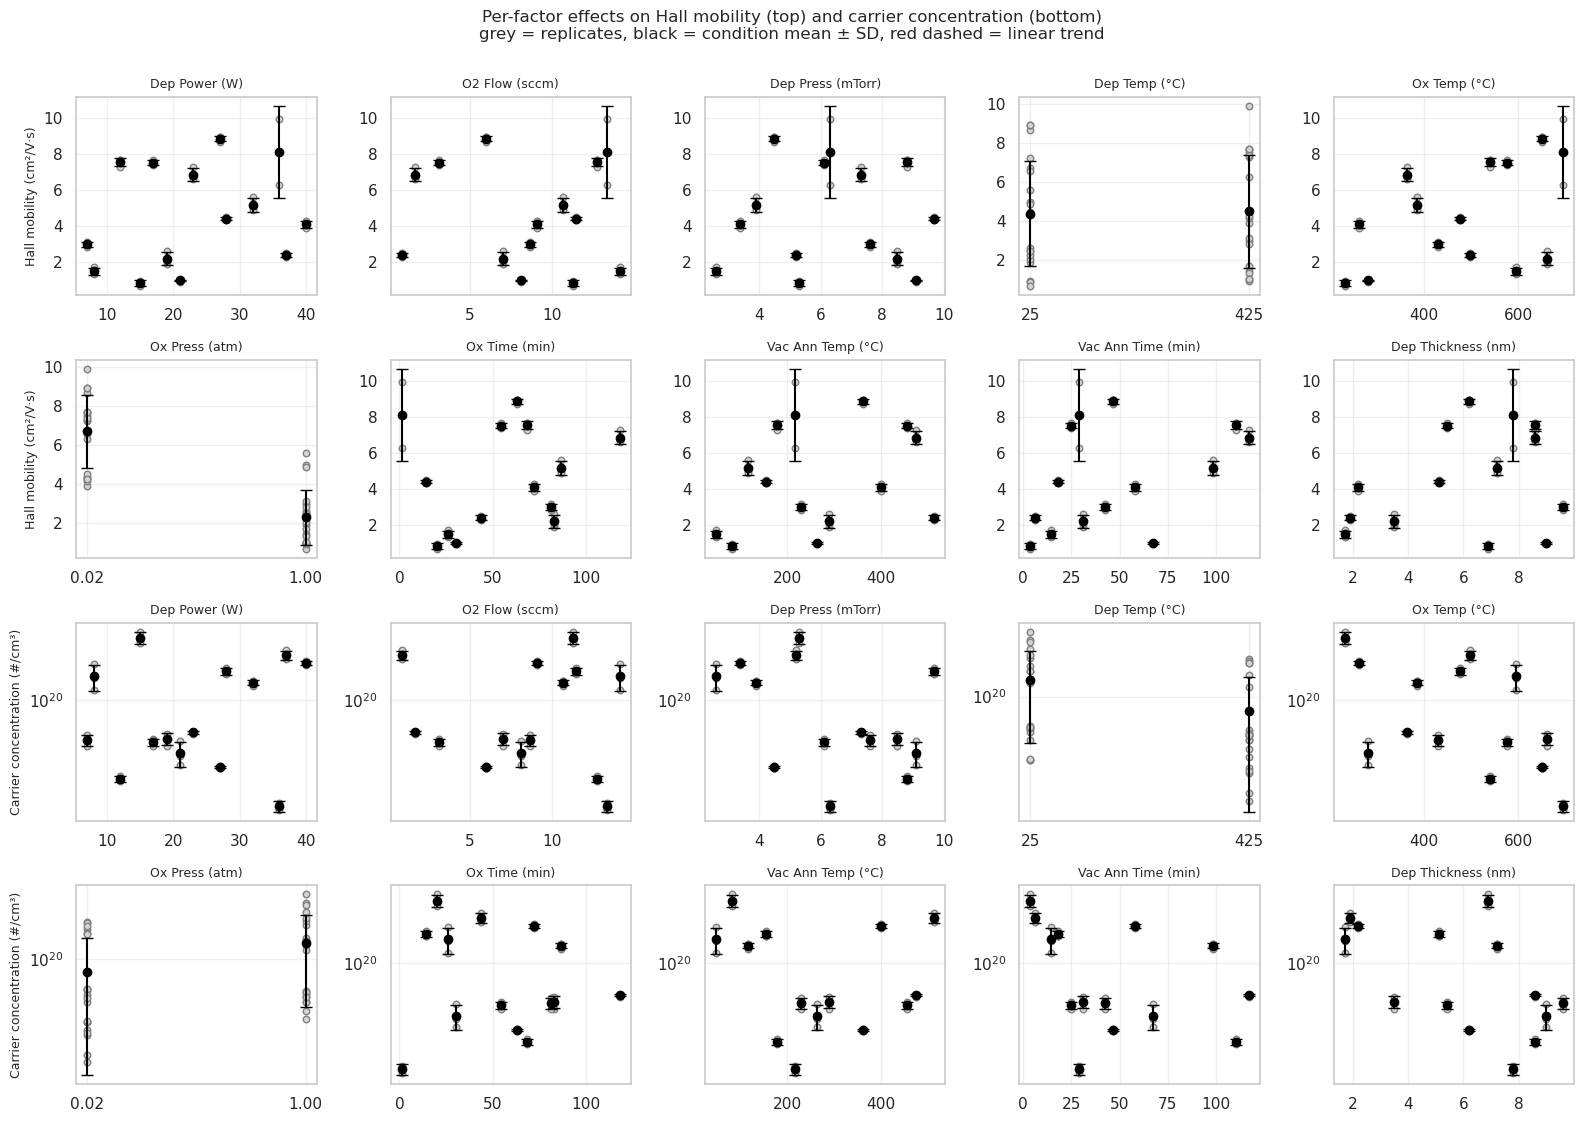

In [157]:
# Two-row grid: row 0 = mobility, row 1 = carrier concentration.
n_factors = len(FACTORS)
ncols = 5
nrows_per_resp = math.ceil(n_factors / ncols)

fig, axes = plt.subplots(2 * nrows_per_resp, ncols, figsize=(3.2 * ncols, 2.8 * 2 * nrows_per_resp))
axes = np.atleast_2d(axes)

def panel(ax, sub, fcol, ycol, log_y):
    is_cat = isinstance(PDO_CONFIG[fcol], list)
    # raw replicates
    if is_cat:
        xcol = fcol + '_lbl'
        order = sorted(sub[xcol].unique())
        for k, lvl in enumerate(order):
            v = sub.loc[sub[xcol] == lvl, ycol].values
            ax.scatter([k] * len(v), v, color='lightgray', edgecolor='gray', s=22, zorder=1)
            if len(v) > 0:
                ax.errorbar(k, np.mean(v), yerr=(np.std(v, ddof=1) if len(v) > 1 else 0),
                            fmt='o', color='black', ms=6, capsize=4, zorder=3)
        ax.set_xticks(range(len(order))); ax.set_xticklabels(order)
    else:
        ax.scatter(sub[fcol], sub[ycol], color='lightgray', edgecolor='gray', s=22, zorder=1)
        cond_means = sub.groupby('Base_Run_ID').agg(x=(fcol, 'first'),
                                                     y_mean=(ycol, 'mean'),
                                                     y_std=(ycol, 'std')).reset_index()
        ax.errorbar(cond_means['x'], cond_means['y_mean'], yerr=cond_means['y_std'].fillna(0),
                    fmt='o', color='black', ms=6, capsize=4, zorder=3)
        # Linear trend on condition means.
        if cond_means['x'].nunique() >= 2:
            xs = np.linspace(cond_means['x'].min(), cond_means['x'].max(), 50)
            slope, intercept, r, p, _ = stats.linregress(cond_means['x'], cond_means['y_mean'])
            # ax.plot(xs, intercept + slope * xs, 'r--', lw=1.5, zorder=2,
            #         label=f'r={r:.2f}, p={p:.2g}')
            ax.legend(fontsize=7, loc='best', frameon=False)
    if log_y:
        ax.set_yscale('log')
    ax.set_title(fcol, fontsize=9)
    ax.grid(True, alpha=0.3)

# Top half: mobility; bottom half: carrier concentration.
for resp_idx, (resp_col, resp_label, log_y) in enumerate(RESPONSES):
    sub = plot_df.dropna(subset=[resp_col])
    for k, fcol in enumerate(FACTORS):
        r = resp_idx * nrows_per_resp + (k // ncols)
        c = k % ncols
        panel(axes[r, c], sub, fcol, resp_col, log_y)
        if c == 0:
            axes[r, c].set_ylabel(resp_label, fontsize=9)
    # Hide unused panels in this response's rows.
    used = n_factors
    for k in range(used, nrows_per_resp * ncols):
        r = resp_idx * nrows_per_resp + (k // ncols)
        c = k % ncols
        axes[r, c].set_visible(False)

fig.suptitle('Per-factor effects on Hall mobility (top) and carrier concentration (bottom)\n'
             'grey = replicates, black = condition mean ± SD, red dashed = linear trend',
             y=1.0, fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'per_factor_effects.png'), dpi=200, bbox_inches='tight')
plt.show()


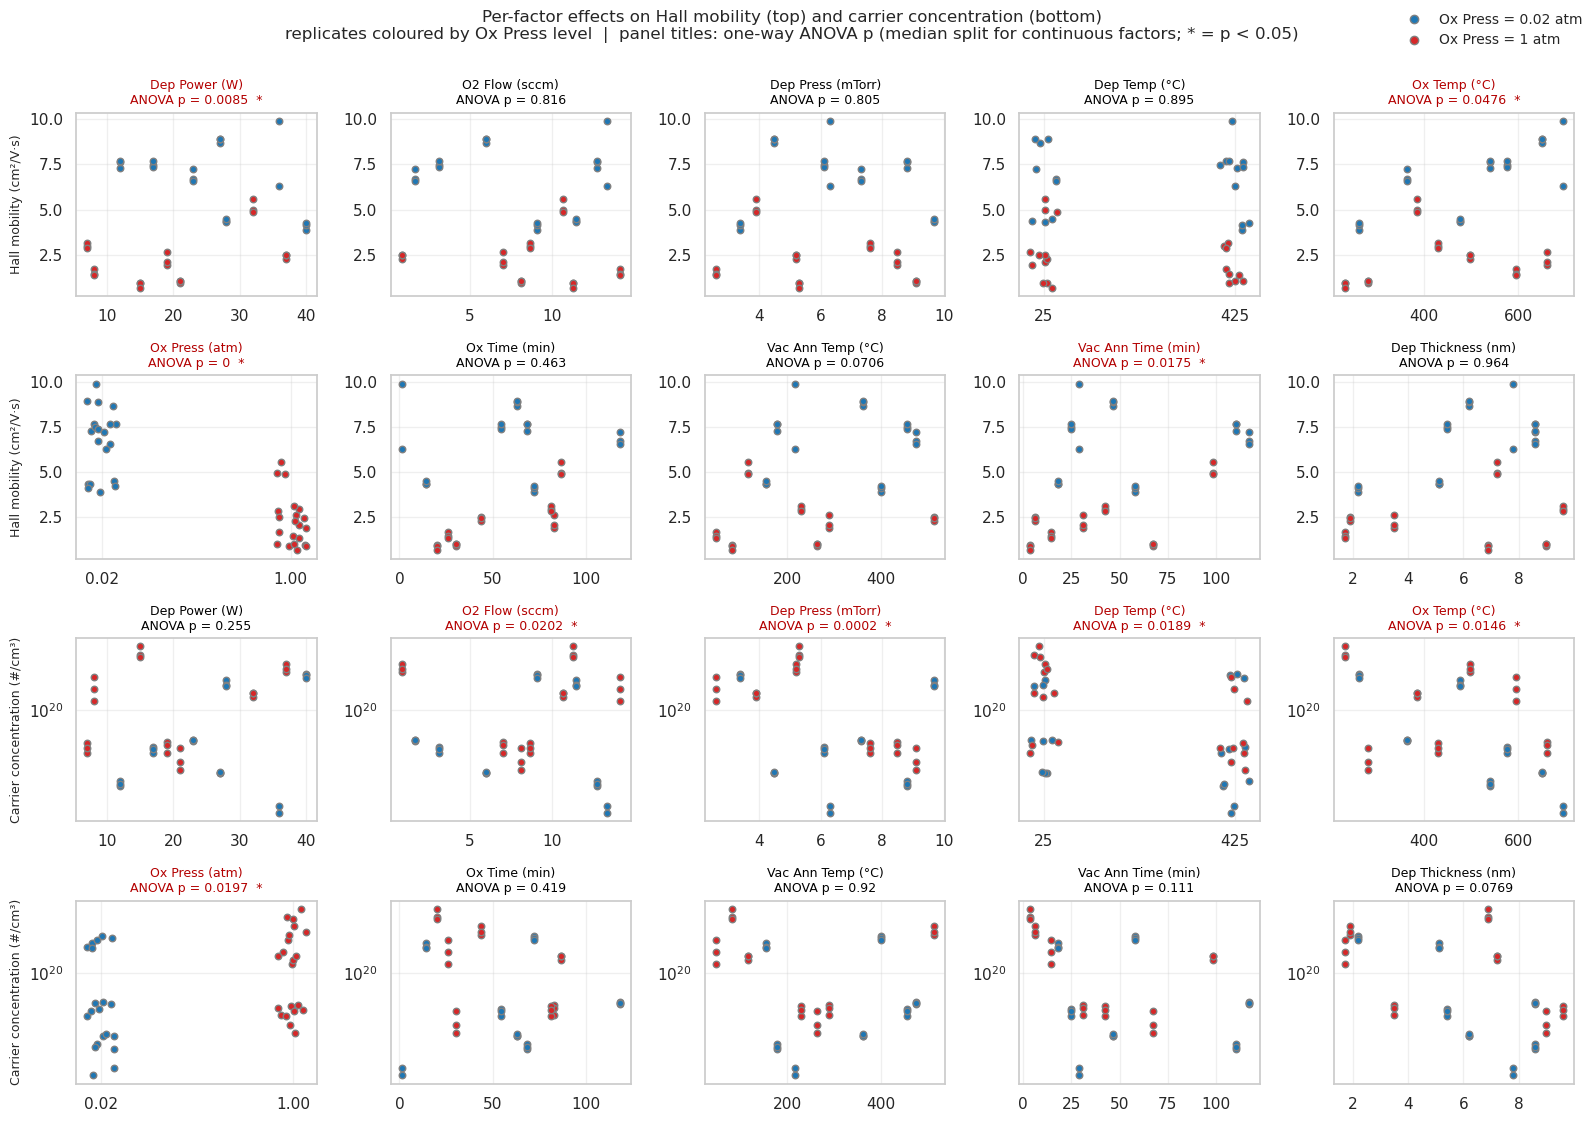

In [158]:
# --- Same per-factor grid, but replicate dots coloured by Ox Press (atm) level ---
# Ox Press is binary in the design (0.02 vs 1.0 atm); colour the replicates by that level
# to see whether the two oxidation-pressure regimes separate on each factor.
OXP_COL = 'Ox Press (atm)'
oxp_levels  = sorted(plot_df[OXP_COL].dropna().unique())          # [0.02, 1.0]
oxp_palette = dict(zip(oxp_levels, ['#1f77b4', '#d62728']))       # blue = low, red = high

# Per-factor one-way ANOVA p-values (from the ANOVA cell above): mobility -> anova_mob,
# log10 carrier -> anova_carr. Surfaced in each panel title so significance is easy to read.
P_BY_RESP = {RESP: dict(zip(anova_mob['factor'],  anova_mob['p_value'])),
             CARR: dict(zip(anova_carr['factor'], anova_carr['p_value']))}

fig, axes = plt.subplots(2 * nrows_per_resp, ncols,
                         figsize=(3.2 * ncols, 2.8 * 2 * nrows_per_resp))
axes = np.atleast_2d(axes)

def panel_oxp(ax, sub, fcol, ycol, log_y):
    is_cat = isinstance(PDO_CONFIG[fcol], list)
    if is_cat:
        xcol  = fcol + '_lbl'
        order = sorted(sub[xcol].unique())
        pos   = {lvl: k for k, lvl in enumerate(order)}
        for lvl, color in oxp_palette.items():
            m = sub[OXP_COL] == lvl
            xs = sub.loc[m, xcol].map(pos)
            # small horizontal jitter so stacked replicates at the same level are visible
            xs = xs + np.random.uniform(-0.08, 0.08, size=len(xs))
            ax.scatter(xs, sub.loc[m, ycol],
                       color=color, edgecolor='gray', s=22, zorder=1)
        ax.set_xticks(range(len(order))); ax.set_xticklabels(order)
    else:
        for lvl, color in oxp_palette.items():
            m = sub[OXP_COL] == lvl
            ax.scatter(sub.loc[m, fcol], sub.loc[m, ycol],
                       color=color, edgecolor='gray', s=22, zorder=1)
    if log_y:
        ax.set_yscale('log')
    p = P_BY_RESP.get(ycol, {}).get(fcol, np.nan)
    sig = np.isfinite(p) and p < 0.05
    ptxt = f'ANOVA p = {p:.3g}' if np.isfinite(p) else 'ANOVA p = n/a'
    ax.set_title(f'{fcol}\n{ptxt}' + ('  *' if sig else ''),
                 fontsize=9, color='#b30000' if sig else 'black')
    ax.grid(True, alpha=0.3)

for resp_idx, (resp_col, resp_label, log_y) in enumerate(RESPONSES):
    sub = plot_df.dropna(subset=[resp_col])
    for k, fcol in enumerate(FACTORS):
        r = resp_idx * nrows_per_resp + (k // ncols)
        c = k % ncols
        panel_oxp(axes[r, c], sub, fcol, resp_col, log_y)
        if c == 0:
            axes[r, c].set_ylabel(resp_label, fontsize=9)
    for k in range(n_factors, nrows_per_resp * ncols):
        r = resp_idx * nrows_per_resp + (k // ncols)
        c = k % ncols
        axes[r, c].set_visible(False)

# Single shared legend for the Ox Press colours.
handles = [plt.Line2D([0], [0], marker='o', linestyle='', color=oxp_palette[lvl],
                      markeredgecolor='gray', label=f'Ox Press = {lvl:g} atm')
           for lvl in oxp_levels]
fig.legend(handles=handles, loc='upper right', frameon=False, fontsize=10)
fig.suptitle('Per-factor effects on Hall mobility (top) and carrier concentration (bottom)\n'
             'replicates coloured by Ox Press level  |  panel titles: one-way ANOVA p '
             '(median split for continuous factors; * = p < 0.05)',
             y=1.0, fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'per_factor_effects_by_oxpress.png'), dpi=200, bbox_inches='tight')
plt.show()

In [159]:
# Save Pearson r and p for every continuous factor against both responses, so the
# numbers behind the red dashed lines are stored alongside the picture.
rows = []
for fcol in CONT_FACTORS:
    for (resp_col, resp_label, _) in RESPONSES:
        cond_means = plot_df.dropna(subset=[resp_col]).groupby('Base_Run_ID').agg(
            x=(fcol, 'first'), y=(resp_col, 'mean')).reset_index()
        if cond_means['x'].nunique() < 2:
            rows.append({'factor': fcol, 'response': resp_label, 'pearson_r': np.nan,
                         'p_value': np.nan, 'slope_per_unit': np.nan, 'n_conditions': len(cond_means)})
            continue
        slope, intercept, r, p, _ = stats.linregress(cond_means['x'], cond_means['y'])
        rows.append({'factor': fcol, 'response': resp_label,
                     'pearson_r': round(float(r), 3), 'p_value': round(float(p), 4),
                     'slope_per_unit': float(f'{slope:.3g}'), 'n_conditions': len(cond_means)})
# Binary factors: report difference of means.
for fcol in CAT_FACTORS:
    for (resp_col, resp_label, _) in RESPONSES:
        sub = plot_df.dropna(subset=[resp_col])
        groups = [sub.loc[sub[fcol] == lvl, resp_col].values for lvl in sorted(sub[fcol].unique())]
        if len(groups) < 2 or any(len(g) == 0 for g in groups):
            rows.append({'factor': fcol, 'response': resp_label, 'pearson_r': np.nan,
                         'p_value': np.nan, 'slope_per_unit': np.nan, 'n_conditions': sum(map(len, groups))})
            continue
        F, p = stats.f_oneway(*groups)
        rows.append({'factor': fcol, 'response': resp_label,
                     'pearson_r': np.nan, 'p_value': round(float(p), 4),
                     'slope_per_unit': f'mean_high - mean_low = {np.mean(groups[1]) - np.mean(groups[0]):.3g}',
                     'n_conditions': sub['Base_Run_ID'].nunique()})

effect_df = pd.DataFrame(rows)
effect_df.to_excel(os.path.join(OUT_DIR, 'factor_effects_summary.xlsx'), index=False)
effect_df


,factor,response,pearson_r,p_value,slope_per_unit,n_conditions
0,Dep Power (W),Hall mobility (cm²/V·s),0.247,0.3954,0.0646,14
1,Dep Power (W),Carrier concentration (#/cm³),0.200,0.4938,1590000000000000000.0,14
2,O2 Flow (sccm),Hall mobility (cm²/V·s),-0.117,0.6895,-0.0766,14
3,O2 Flow (sccm),Carrier concentration (#/cm³),0.072,0.8063,1430000000000000000.0,14
4,Dep Press (mTorr),Hall mobility (cm²/V·s),0.012,0.9683,0.0146,14
5,Dep Press (mTorr),Carrier concentration (#/cm³),-0.423,0.1322,-16000000000000000000.0,14
6,Ox Temp (°C),Hall mobility (cm²/V·s),0.466,0.0928,0.00853,14
7,Ox Temp (°C),Carrier concentration (#/cm³),-0.530,0.0513,-295000000000000000.0,14
8,Ox Time (min),Hall mobility (cm²/V·s),0.221,0.4486,0.0188,14
9,Ox Time (min),Carrier concentration (#/cm³),-0.274,0.3433,-708000000000000000.0,14


## 7. Sobol Batch 2 — capping Vac Ann Temp only

The contact-fail conditions in Batch 1 share a clear signal: every fully-failed condition annealed at high `Vac Ann Temp` (≥ ~580 °C), while every surviving condition had `Vac Ann Temp ≤ ~510 °C`. `Ox Temp` is **not** cleanly separated — high-`Ox Temp` runs survived (e.g. #14, #15 at ~650–700 °C) — so we keep `Ox Temp` at its full range and **cap only `Vac Ann Temp`** (≤ 550 °C, matching the §8 optimization domain).

Sobol sequences support **incremental extension**: continuing the same `qmc.Sobol` instance past Batch 1 keeps the cumulative point set low-discrepancy in the 10-D unit hypercube. We:

1. **Continue the same sequence** (do *not* re-seed) so Batch 2's 23 points fill the gaps left by Batch 1.
2. **Cap only the `Vac Ann Temp` mapping**; the Sobol u-values still cover [0, 1] uniformly — only the affine scaling to °C changes for that one factor.

The temperature-plane plot marks the **infeasible (contact-fail) Batch 1 conditions with a black ×**, so you can see the new design steers away from that region.

In [160]:
# --- Batch 2 configuration: continue Sobol, cap ONLY Vac Ann Temp ---
# Decision: cap only Vac Ann Temp (all fully-failed runs annealed > ~580 C). Ox Temp keeps
# its original 200-800 range. Cap value aligned to the §8 optimization domain (550 C).
B2_VAC_ANN_TEMP_MAX = 550.0   # was 800
N_BATCH2 = 23

PDO_CONFIG_B2 = {**PDO_CONFIG}  # shallow copy, then overwrite ONLY Vac Ann Temp
PDO_CONFIG_B2['Vac Ann Temp (°C)'] = {'min': 25.0, 'max': B2_VAC_ANN_TEMP_MAX, 'decimals': 1}

# Reconstruct the Sobol sampler with the same seed AND advance it past the points
# already consumed by Batch 1 (we used `random(n=23*5)=115` draws to produce 23 rows).
# This keeps the cumulative design low-discrepancy in the unit hypercube.
sampler_b2 = qmc.Sobol(d=len(PDO_CONFIG_B2), scramble=True, seed=GLOBAL_SEED)
_ = sampler_b2.random(n=N_BATCH2 * 5)   # burn the same number of draws Batch 1 consumed

# Generate Batch 2 from the continued sequence
df_pdo_b2_plan, _ = generate_doe(N_BATCH2, PDO_CONFIG_B2, sampler=sampler_b2, seed=None)
df_pdo_b2_plan['Batch'] = 'Batch 2'
df_pdo_b2_full = add_replicates(df_pdo_b2_plan, NUM_REPLICATES)

print(f'Batch 2 generated: {df_pdo_b2_full.shape[0]} rows ({N_BATCH2} conditions × {NUM_REPLICATES} replicates)')
print(f'Ox Temp range  : [{df_pdo_b2_plan["Ox Temp (°C)"].min():.1f}, {df_pdo_b2_plan["Ox Temp (°C)"].max():.1f}]  (uncapped, 200-800)')
print(f'Vac Ann range  : [{df_pdo_b2_plan["Vac Ann Temp (°C)"].min():.1f}, {df_pdo_b2_plan["Vac Ann Temp (°C)"].max():.1f}]  (cap = {B2_VAC_ANN_TEMP_MAX})')
df_pdo_b2_plan.head()

Batch 2 generated: 69 rows (23 conditions × 3 replicates)
Ox Temp range  : [216.8, 768.7]  (uncapped, 200-800)
Vac Ann range  : [33.9, 548.8]  (cap = 550.0)


,Dep Power (W),O2 Flow (sccm),Dep Press (mTorr),Dep Temp (°C),Ox Temp (°C),Ox Press (atm),Ox Time (min),Vac Ann Temp (°C),Vac Ann Time (min),Dep Thickness (nm),Batch
0,10.0,10.6,6.1,425.0,491.8,1.00,115.9,408.7,84.6,8.2,Batch 2
1,15.0,0.7,9.0,425.0,379.3,1.00,8.7,33.9,50.5,4.6,Batch 2
2,31.0,12.8,5.0,25.0,580.2,0.02,104.2,336.6,66.2,7.0,Batch 2
3,22.0,5.4,7.8,425.0,684.0,0.02,42.1,433.3,97.5,9.7,Batch 2
4,7.0,18.1,2.2,25.0,276.8,1.00,70.3,198.6,25.6,2.9,Batch 2


In [161]:
# --- Distribution quality: Batch 1 alone, Batch 2 alone, Batch 1 + 2 cumulative ---
from scipy.spatial.distance import pdist

def normalise_for_metrics(df_in, config):
    cols = [c for c in df_in.columns if c in config]
    M = df_in[cols].copy().astype(float)
    for c in cols:
        if isinstance(config[c], list):
            uniq = sorted(set(config[c]))
            M[c] = M[c].map({v: i/(len(uniq)-1) if len(uniq) > 1 else 0.0 for i, v in enumerate(uniq)})
        else:
            lo, hi = config[c]['min'], config[c]['max']
            M[c] = (M[c] - lo) / (hi - lo) if hi > lo else 0.0
    return np.clip(M.values, 0.0, 1.0)

# Only Vac Ann Temp is capped now, so we count how many Batch 1 conditions exceed that cap
# (these are the high-anneal runs Batch 2 intentionally avoids).
b1_plan = df_pdo_plan_full.drop_duplicates('Base_Run_ID')[FACTORS]
b2_plan = df_pdo_b2_full.drop_duplicates('Base_Run_ID')[FACTORS]
cum_plan = pd.concat([b1_plan, b2_plan], ignore_index=True)

b1_outside_cap = (b1_plan['Vac Ann Temp (°C)'] > B2_VAC_ANN_TEMP_MAX).sum()

metric_rows = []
for label, frame in [('Batch 1 (23 conds, original bounds)', b1_plan),
                     ('Batch 2 (23 conds, Vac Ann capped)',  b2_plan),
                     ('Batch 1 + Batch 2 cumulative',       cum_plan)]:
    M = normalise_for_metrics(frame, PDO_CONFIG_B2)
    disc = qmc.discrepancy(M)
    md  = pdist(M).min() if len(M) > 1 else np.nan
    metric_rows.append({'design': label, 'n_conditions': len(frame),
                        'discrepancy': round(float(disc), 4),
                        'min_pairwise_dist': round(float(md), 4)})
metrics_b2 = pd.DataFrame(metric_rows)
metrics_b2.to_excel(os.path.join(OUT_DIR, 'sobol_batch2_metrics.xlsx'), index=False)
print(f'Batch 1 conditions above the Vac Ann cap ({B2_VAC_ANN_TEMP_MAX:g} °C): {b1_outside_cap} / {len(b1_plan)}')
metrics_b2

Batch 1 conditions above the Vac Ann cap (550 °C): 6 / 23


,design,n_conditions,discrepancy,min_pairwise_dist
0,"Batch 1 (23 conds, original bounds)",23,0.7095,0.6722
1,"Batch 2 (23 conds, Vac Ann capped)",23,0.6459,0.7666
2,Batch 1 + Batch 2 cumulative,46,0.5289,0.5386


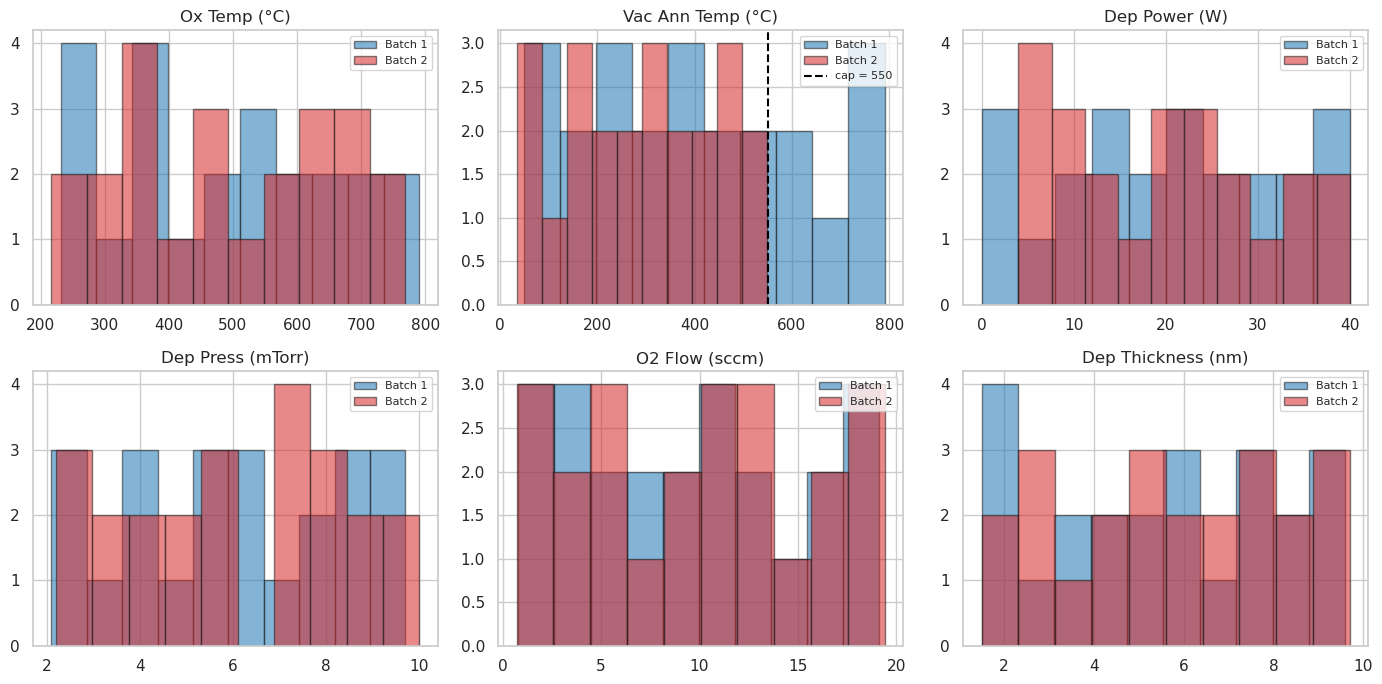

Infeasible (all-replicate contact-fail) conditions: [1, 4, 6, 10, 11, 13, 16, 17, 18]


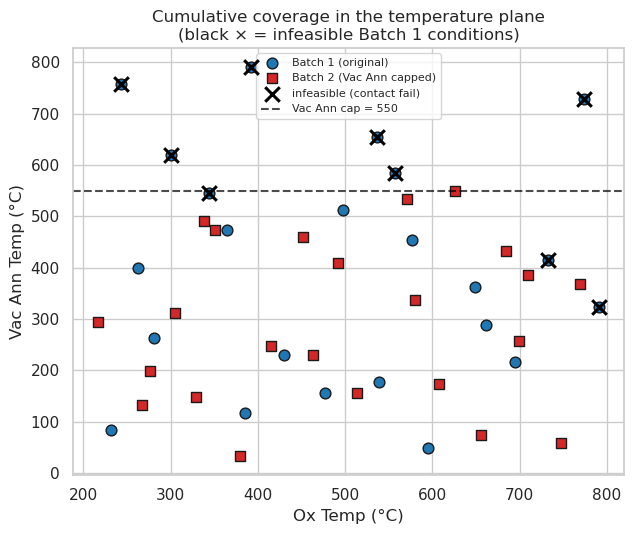

In [162]:
# --- Visualise distributions: Batch 1 vs Batch 2 ---
plot_factors = ['Ox Temp (°C)', 'Vac Ann Temp (°C)', 'Dep Power (W)',
                'Dep Press (mTorr)', 'O2 Flow (sccm)', 'Dep Thickness (nm)']
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, f in zip(axes.flat, plot_factors):
    ax.hist(b1_plan[f], bins=10, alpha=0.55, label='Batch 1', color='#1f77b4', edgecolor='k')
    ax.hist(b2_plan[f], bins=10, alpha=0.55, label='Batch 2', color='#d62728', edgecolor='k')
    # Only Vac Ann Temp is capped now -> single cap line (no Ox Temp line).
    if f == 'Vac Ann Temp (°C)':
        ax.axvline(B2_VAC_ANN_TEMP_MAX, ls='--', color='black', label=f'cap = {B2_VAC_ANN_TEMP_MAX:g}')
    ax.set_title(f); ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'batch2_distributions.png'), dpi=200)
plt.show()

# Infeasible (contact-fail) conditions = those where ALL replicates failed contact.
fail_all = df.groupby('Base_Run_ID')['contact_fail'].all()
infeasible_ids = fail_all[fail_all].index.tolist()
infeasible = df.drop_duplicates('Base_Run_ID').set_index('Base_Run_ID').loc[infeasible_ids]
print(f'Infeasible (all-replicate contact-fail) conditions: {infeasible_ids}')

# Cumulative scatter in the temperature plane: Batch 1, Batch 2, and infeasible marks.
fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.scatter(b1_plan['Ox Temp (°C)'], b1_plan['Vac Ann Temp (°C)'],
           c='#1f77b4', edgecolor='k', s=60, label='Batch 1 (original)')
ax.scatter(b2_plan['Ox Temp (°C)'], b2_plan['Vac Ann Temp (°C)'],
           c='#d62728', edgecolor='k', s=60, marker='s', label='Batch 2 (Vac Ann capped)')
ax.scatter(infeasible['Ox Temp (°C)'], infeasible['Vac Ann Temp (°C)'],
           marker='x', s=110, c='black', linewidths=2.2, zorder=6, label='infeasible (contact fail)')
# Only the Vac Ann cap line (horizontal); Ox Temp is no longer capped.
ax.axhline(B2_VAC_ANN_TEMP_MAX, ls='--', color='black', alpha=0.7, label=f'Vac Ann cap = {B2_VAC_ANN_TEMP_MAX:g}')
ax.set_xlabel('Ox Temp (°C)'); ax.set_ylabel('Vac Ann Temp (°C)')
ax.set_title('Cumulative coverage in the temperature plane\n(black × = infeasible Batch 1 conditions)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'batch2_temp_coverage.png'), dpi=200)
plt.show()

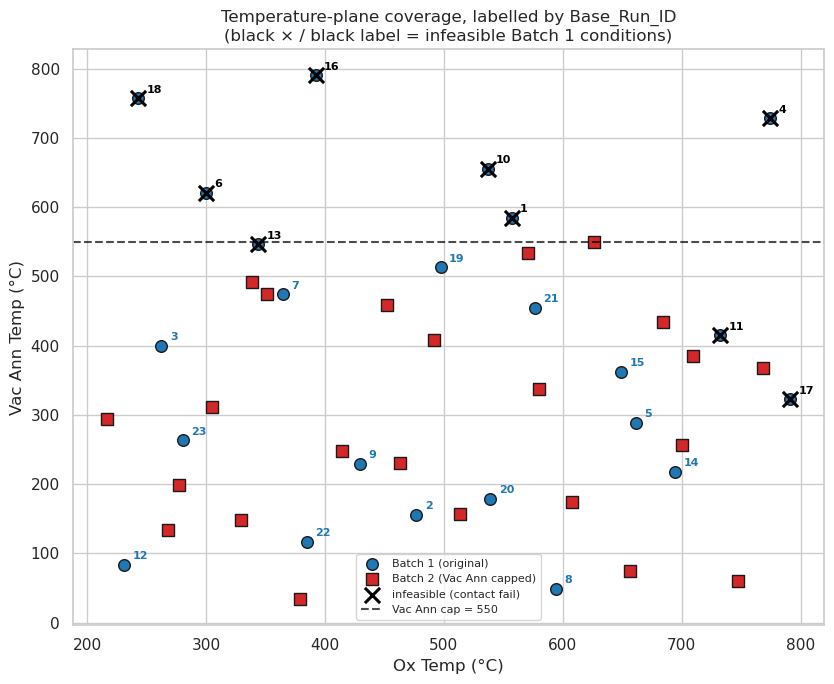

In [163]:
# --- Temperature-plane scatter, every Batch 1 condition labelled with its Base_Run_ID ---
# Same coverage plot as above, but each condition is annotated so individual
# experiments (e.g. 14 and 15) can be located directly on the plot.
# NB: b1_plan keeps only FACTORS columns, so pull the IDs from df_pdo_plan_full.
b1_lbl = df_pdo_plan_full.drop_duplicates('Base_Run_ID')[
    ['Base_Run_ID', 'Ox Temp (°C)', 'Vac Ann Temp (°C)']]

fig, ax = plt.subplots(figsize=(8.5, 7))
ax.scatter(b1_plan['Ox Temp (°C)'], b1_plan['Vac Ann Temp (°C)'],
           c='#1f77b4', edgecolor='k', s=70, label='Batch 1 (original)')
ax.scatter(b2_plan['Ox Temp (°C)'], b2_plan['Vac Ann Temp (°C)'],
           c='#d62728', edgecolor='k', s=70, marker='s', label='Batch 2 (Vac Ann capped)')
ax.scatter(infeasible['Ox Temp (°C)'], infeasible['Vac Ann Temp (°C)'],
           marker='x', s=120, c='black', linewidths=2.2, zorder=6, label='infeasible (contact fail)')
ax.axhline(B2_VAC_ANN_TEMP_MAX, ls='--', color='black', alpha=0.7,
           label=f'Vac Ann cap = {B2_VAC_ANN_TEMP_MAX:g}')

# Annotate each Batch 1 condition with its Base_Run_ID (infeasible ones in black to match the ×).
infeasible_ids_set = set(infeasible.index)
for _, r in b1_lbl.iterrows():
    bid = int(r['Base_Run_ID'])
    ax.annotate(str(bid), (r['Ox Temp (°C)'], r['Vac Ann Temp (°C)']),
                textcoords='offset points', xytext=(6, 4), fontsize=8, fontweight='bold',
                color='black' if bid in infeasible_ids_set else '#1f77b4')

ax.set_xlabel('Ox Temp (°C)'); ax.set_ylabel('Vac Ann Temp (°C)')
ax.set_title('Temperature-plane coverage, labelled by Base_Run_ID\n'
             '(black × / black label = infeasible Batch 1 conditions)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'batch2_temp_coverage_labelled.png'), dpi=200)
plt.show()

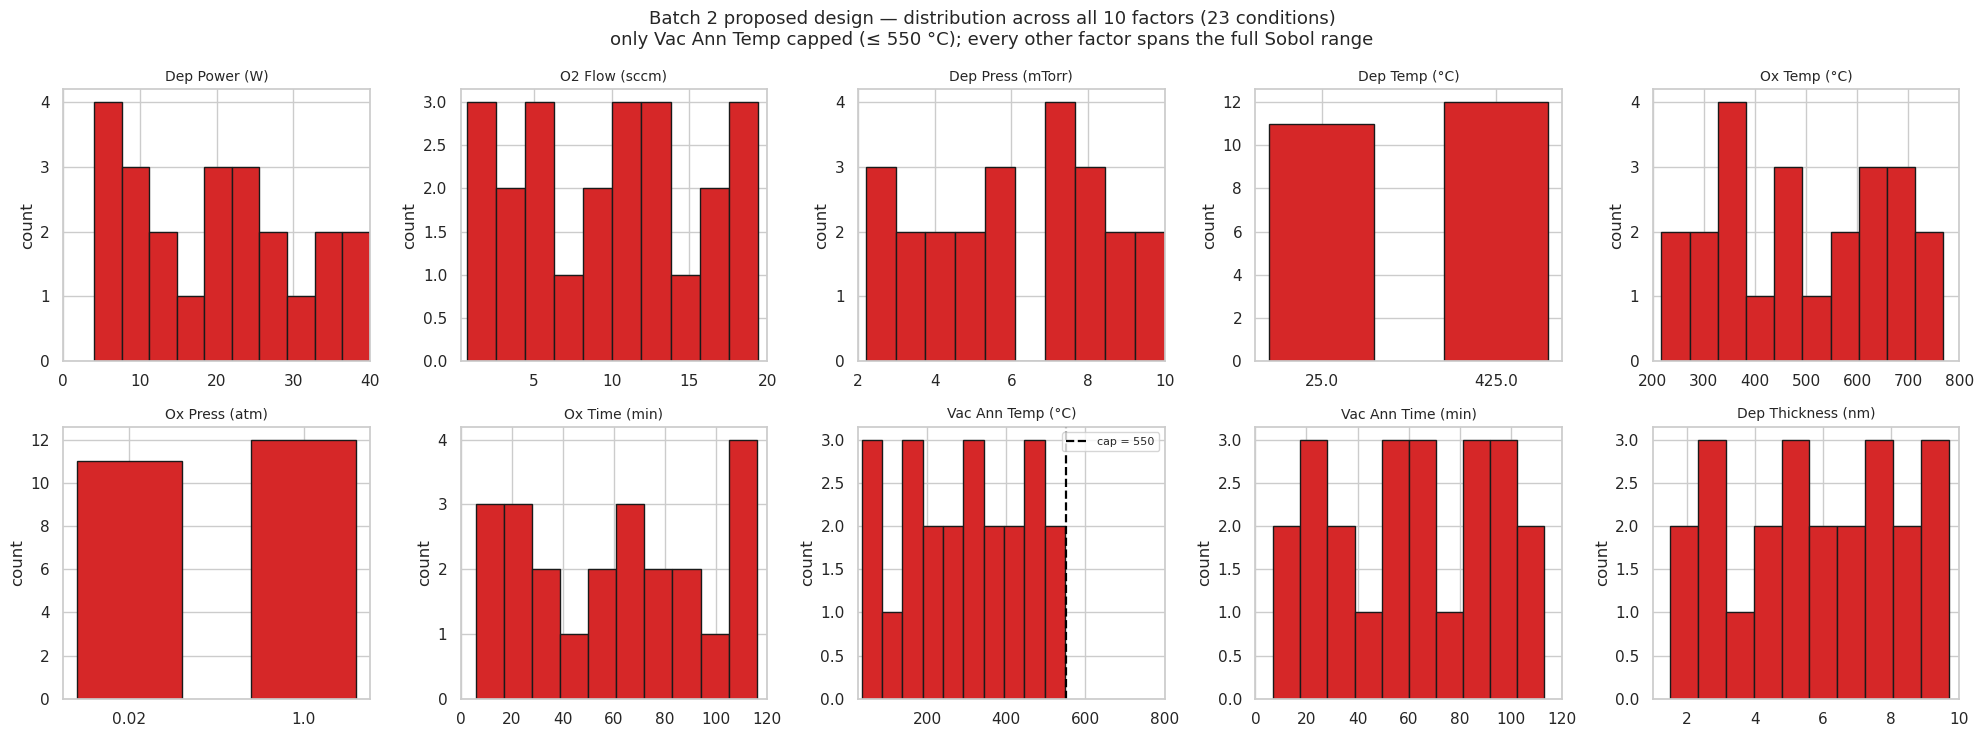

In [164]:
# --- Distribution of the NEW Batch 2 samples across ALL 10 factors ---
fig, axes = plt.subplots(2, 5, figsize=(20, 7.5))
for ax, f in zip(axes.flat, FACTORS):
    vals = df_pdo_b2_plan[f]
    if isinstance(PDO_CONFIG[f], list):                      # binary factor -> bar of levels
        levels = sorted(PDO_CONFIG[f])
        counts = [int((vals == lv).sum()) for lv in levels]
        ax.bar([str(lv) for lv in levels], counts, color='#d62728', edgecolor='k', width=0.6)
    else:
        ax.hist(vals, bins=10, color='#d62728', edgecolor='k')
        lo, hi = PDO_CONFIG[f]['min'], PDO_CONFIG[f]['max']   # full original range on x
        ax.set_xlim(lo, hi)
        if f == 'Vac Ann Temp (°C)':                      # show the cap as a line
            ax.axvline(B2_VAC_ANN_TEMP_MAX, ls='--', color='black', lw=1.6,
                       label=f'cap = {B2_VAC_ANN_TEMP_MAX:g}')
            ax.legend(fontsize=8)
    ax.set_title(f, fontsize=10); ax.set_ylabel('count')
fig.suptitle(f'Batch 2 proposed design — distribution across all 10 factors ({N_BATCH2} conditions)\n'
             f'only Vac Ann Temp capped (≤ {B2_VAC_ANN_TEMP_MAX:g} °C); every other factor spans the full Sobol range',
             fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'batch2_all_factor_distributions.png'), dpi=200, bbox_inches='tight')
plt.show()

In [165]:
# --- Export Batch 2 design (and the cumulative plan) for fabrication ---
b2_path = os.path.join(OUT_DIR, 'PdO_DoE_Batch2_capped.xlsx')
df_b1_with_label = df_pdo_plan_full.copy()
df_b1_with_label['Batch'] = 'Batch 1'
df_cum = pd.concat([df_b1_with_label, df_pdo_b2_full], ignore_index=True)
df_cum['Cumulative_Run_ID'] = df_cum.groupby(['Batch','Base_Run_ID']).ngroup() + 1

with pd.ExcelWriter(b2_path) as w:
    df_pdo_b2_full.to_excel(w, sheet_name='Batch2_full',     index=False)
    df_pdo_b2_plan.to_excel(w, sheet_name='Batch2_unique',   index=False)
    df_cum.to_excel       (w, sheet_name='Batch1_plus_2',    index=False)
    metrics_b2.to_excel   (w, sheet_name='design_metrics',   index=False)
    pd.DataFrame([
        {'parameter': 'Ox Temp (°C) max',      'Batch 1': 800.0, 'Batch 2': 800.0},
        {'parameter': 'Vac Ann Temp (°C) max', 'Batch 1': 800.0, 'Batch 2': B2_VAC_ANN_TEMP_MAX},
        {'parameter': 'capped factors',        'Batch 1': '—', 'Batch 2': 'Vac Ann Temp only'},
        {'parameter': 'seed',                  'Batch 1': GLOBAL_SEED, 'Batch 2': GLOBAL_SEED},
        {'parameter': 'sampler continued',     'Batch 1': '—', 'Batch 2': 'yes (advanced past Batch 1 draws)'},
    ]).to_excel(w, sheet_name='config_diff', index=False)
print(f'Saved: {b2_path}')
df_pdo_b2_plan

Saved: output/experiment02_update_all_sobol/PdO_DoE_Batch2_capped.xlsx


,Dep Power (W),O2 Flow (sccm),Dep Press (mTorr),Dep Temp (°C),Ox Temp (°C),Ox Press (atm),Ox Time (min),Vac Ann Temp (°C),Vac Ann Time (min),Dep Thickness (nm),Batch
0,10.0,10.6,6.1,425.0,491.8,1.00,115.9,408.7,84.6,8.2,Batch 2
1,15.0,0.7,9.0,425.0,379.3,1.00,8.7,33.9,50.5,4.6,Batch 2
2,31.0,12.8,5.0,25.0,580.2,0.02,104.2,336.6,66.2,7.0,Batch 2
3,22.0,5.4,7.8,425.0,684.0,0.02,42.1,433.3,97.5,9.7,Batch 2
4,7.0,18.1,2.2,25.0,276.8,1.00,70.3,198.6,25.6,2.9,Batch 2
5,8.0,5.2,7.1,25.0,747.0,1.00,6.9,59.5,53.9,8.5,Batch 2
6,23.0,12.2,2.9,425.0,216.8,0.02,91.2,294.5,70.1,1.9,Batch 2
7,35.0,9.7,8.2,25.0,452.2,0.02,32.4,459.0,94.1,3.6,Batch 2
8,19.0,17.3,5.8,425.0,513.8,1.00,64.3,156.5,21.6,5.7,Batch 2
9,14.0,7.5,3.1,425.0,626.3,1.00,50.7,548.8,113.0,2.6,Batch 2


### How to read these results

- `sobol_batch2_metrics.xlsx` reports **discrepancy** (lower = better space-filling) and **min pairwise distance** (higher = better separation) under the same normalisation. Compare Batch 1, Batch 2, and the cumulative design.
- `batch2_distributions.png` shows Batch 1 vs Batch 2 for six factors; only `Vac Ann Temp` is truncated (≤ 550 °C), the others still span their full ranges.
- `batch2_temp_coverage.png` overlays Batch 1 and Batch 2 in the (Ox Temp, Vac Ann Temp) plane, with the **infeasible contact-fail conditions marked as black ×** — they all sit at high Vac Ann Temp, which the cap excludes (the single dashed line is the Vac Ann cap; Ox Temp is no longer capped).
- `batch2_all_factor_distributions.png` shows the distribution of the new Batch 2 samples across **all 10 factors**.
- `PdO_DoE_Batch2_capped.xlsx` contains the new 23 conditions × 3 replicates, plus a `Batch1_plus_2` sheet with cumulative IDs ready to hand to fabrication.

To use a different Vac Ann cap, change `B2_VAC_ANN_TEMP_MAX` and re-run this section — nothing upstream changes.

## 8. Multi-objective Bayesian optimization (botorch)

The linear models in §5 confirmed a simple surface is not predictive at this sample size, so for choosing the next experiments we switch to a **Gaussian-process surrogate + multi-objective acquisition** (botorch), which is built for small, noisy, high-dimensional data.

**Goal (two competing objectives):**
- **maximize** Hall mobility, and
- **minimize** carrier concentration.

**Design choices (per request):**
- Train only on the **valid** (non-contact-fail) conditions — failures are *not* modeled.
- Constrain the search so **`Vac Ann Temp ≤ 550 °C`**; all other factors keep their original ranges.
- Acquisition: **`qLogNoisyExpectedHypervolumeImprovement`** (qLogNEHVI), proposing a batch of **3** new recipes.

Outputs: `botorch_training_data.xlsx`, `botorch_proposed_candidates.xlsx`, `botorch_pareto_candidates.png`, `botorch_candidates_parallel_coords.png`.

In [166]:
# --- botorch multi-objective setup ---
# The GP surrogate + BO machinery now live in `utils/mobo.py` so the exact same
# model structure and acquisition loop can be reused for a reduced 1-D test
# (see utils/mobo.py docstring). This cell only keeps the PROBLEM definition
# (bounds, categorical levels, training table); the model/BO calls are below.
import sys
if REPO_ROOT not in sys.path:           # make the repo-root `utils` package importable
    sys.path.insert(0, REPO_ROOT)
import torch
import utils.mobo as mobo

torch.manual_seed(GLOBAL_SEED)
tkw = {'dtype': torch.double}

# Per request: the optimization domain caps Vac Ann Temp at 550 C (failures all annealed
# above ~580 C) AND Ox Temp at 680 C. The Vac Ann cap is baked into BO_CONT_BOUNDS so it
# also shrinks the encoding; the Ox Temp cap is applied ONLY to the candidate search bounds
# (see the proposal cell) so the GP is still trained on every observed condition at its
# true Ox Temp -- no clipping/distortion of the high-temperature training points.
BO_VAC_ANN_MAX = 550.0
BO_OX_TEMP_MAX = 680.0   # restricts proposed recipes only; training uses the full 200-800 range
BO_CONT_BOUNDS = {
    'Dep Power (W)':      (0.0,   40.0),
    'O2 Flow (sccm)':     (0.3,   20.0),
    'Dep Press (mTorr)':  (2.0,   10.0),
    'Ox Temp (°C)':       (200.0, 800.0),
    'Ox Time (min)':      (0.0,   120.0),
    'Vac Ann Temp (°C)':  (25.0,  BO_VAC_ANN_MAX),   # capped
    'Vac Ann Time (min)': (0.0,   120.0),
    'Dep Thickness (nm)': (1.0,   10.0),
}
BO_CAT_LEVELS = {'Dep Temp (°C)': [25.0, 425.0], 'Ox Press (atm)': [0.02, 1.0]}
DECIMALS = {f: (PDO_CONFIG[f]['decimals'] if isinstance(PDO_CONFIG[f], dict) else 1) for f in FACTORS}

# Thin wrappers around the generic encoders so downstream cells keep their names.
def to_unit(df):
    return mobo.encode_unit(df, FACTORS, BO_CONT_BOUNDS, BO_CAT_LEVELS)

def from_unit(U):
    return mobo.decode_unit(U, FACTORS, BO_CONT_BOUNDS, BO_CAT_LEVELS, DECIMALS)

# Training set: one row per valid condition (means over replicates). `valid` has both
# responses numeric and contact-fail rows already dropped.
bo_cond = (valid.dropna(subset=[RESP, CARR])
                .groupby('Base_Run_ID')
                .agg({**{f: 'first' for f in FACTORS}, RESP: 'mean', CARR: 'mean'})
                .reset_index())
bo_cond['log10_carrier'] = np.log10(bo_cond[CARR])
print(f'Training conditions for BO: {len(bo_cond)}')
print(f'Mobility range : {bo_cond[RESP].min():.2f} – {bo_cond[RESP].max():.2f} cm²/V·s')
print(f'Carrier range  : {bo_cond[CARR].min():.2e} – {bo_cond[CARR].max():.2e} cm⁻³')
print(f'Vac Ann range in training data: {bo_cond["Vac Ann Temp (°C)"].min():.1f} – {bo_cond["Vac Ann Temp (°C)"].max():.1f} °C (cap = {BO_VAC_ANN_MAX})')
print(f'Ox Temp range in training data: {bo_cond["Ox Temp (°C)"].min():.1f} – {bo_cond["Ox Temp (°C)"].max():.1f} °C (proposal cap = {BO_OX_TEMP_MAX}; training uncapped)')

Training conditions for BO: 14
Mobility range : 0.84 – 8.84 cm²/V·s
Carrier range  : 1.64e+19 – 2.90e+20 cm⁻³
Vac Ann range in training data: 48.9 – 512.8 °C (cap = 550.0)
Ox Temp range in training data: 231.1 – 694.7 °C (proposal cap = 680.0; training uncapped)


### 8.1  Surrogate model and Pareto front

We fit a 2-output Gaussian process (`SingleTaskGP`, inputs normalized to [0,1], outcomes standardized) on the **14 valid condition means**. botorch always *maximizes*, so the objective vector is `[Hall mobility, −log10(carrier)]` — maximizing the second entry is exactly minimizing carrier concentration. Carrier is modeled in `log10` because it spans more than a decade.

The cell also computes the **observed Pareto front** (conditions not dominated on both objectives) and its **hypervolume** above a reference point. Hypervolume is the scalar the acquisition function tries to grow.

In [167]:
# --- Fit the multi-output GP surrogate (with observation noise) and compute the Pareto front ---
# Objectives for botorch (which always MAXIMIZES): [Hall mobility, -log10(carrier)].
# Maximizing -log10(carrier) is the same as minimizing carrier concentration.
X = torch.tensor(to_unit(bo_cond), **tkw)
Y = torch.tensor(np.c_[bo_cond[RESP].values, -bo_cond['log10_carrier'].values], **tkw)
d = len(FACTORS)
assert (X.min() >= 0) and (X.max() <= 1), 'training inputs must lie inside the optimization bounds'

# y_var: each training target is a per-condition MEAN over ~3 replicates, so its
# observation noise is the variance of that mean (SEM^2 = replicate_var / n).
# Carrier is modeled in log10, so its noise is computed on log10(carrier).
# Single-replicate / zero-spread conditions are floored to the median SEM^2.
sem2_mob  = mobo.variance_of_mean_by_group(valid, 'Base_Run_ID', RESP)
sem2_carr = mobo.variance_of_mean_by_group(valid, 'Base_Run_ID', CARR, transform=np.log10)
Yvar = torch.tensor(np.c_[
    sem2_mob.reindex(bo_cond['Base_Run_ID']).values,
    sem2_carr.reindex(bo_cond['Base_Run_ID']).values,
], **tkw)

# Fixed-noise GP: pass the per-point SEM^2 via train_Yvar instead of inferring a
# single homoskedastic noise level. Inputs normalized, outcomes standardized.
model = mobo.fit_gp(X, Y, Yvar=Yvar)

# Observed Pareto front, its dominated hypervolume, and the reference point
# (a fraction below the worst value on each objective, in maximization space).
pareto_mask, obs_hv, ref_point = mobo.pareto_front(Y)
pareto_ids = bo_cond.loc[pareto_mask.numpy(), 'Base_Run_ID'].astype(int).tolist()

# Save the training data (incl. the SEM^2 noise used) and Pareto flag for the record.
train_out = bo_cond[['Base_Run_ID'] + FACTORS + [RESP, CARR, 'log10_carrier']].copy()
train_out['sem2_mobility']      = sem2_mob.reindex(bo_cond['Base_Run_ID']).values
train_out['sem2_log10_carrier'] = sem2_carr.reindex(bo_cond['Base_Run_ID']).values
train_out['on_pareto_front']    = pareto_mask.numpy()
train_out.round(6).to_excel(os.path.join(OUT_DIR, 'botorch_training_data.xlsx'), index=False)

print(f'GP trained on {X.shape[0]} conditions in {d}-D | objectives: [mobility ↑, log10 carrier ↓]')
print(f'Observation noise (y_var): per-point SEM² passed via train_Yvar')
print(f'  median SEM² mobility      : {float(np.median(sem2_mob.values)):.4g} (cm²/V·s)²')
print(f'  median SEM² log10 carrier : {float(np.median(sem2_carr.values)):.4g} dex²')
print(f'Observed Pareto-optimal conditions: {pareto_ids}')
print(f'Reference point [mob, -log10 carr]: {np.round(ref_point.numpy(), 3).tolist()}')
print(f'Observed hypervolume: {obs_hv:.4f}')

GP trained on 14 conditions in 10-D | objectives: [mobility ↑, log10 carrier ↓]
Observation noise (y_var): per-point SEM² passed via train_Yvar
  median SEM² mobility      : 0.009689 (cm²/V·s)²
  median SEM² log10 carrier : 0.0003345 dex²
Observed Pareto-optimal conditions: [14, 15]
Reference point [mob, -log10 carr]: [0.036, -20.588]
Observed hypervolume: 11.8862


### 8.2  Propose 3 candidate recipes (q = 3 batch)

We maximize **q-batch Log Noisy Expected Hypervolume Improvement** (`qLogNEHVI`) — the current state-of-the-art batch multi-objective acquisition, robust to the GP's observation noise. The optimization is *mixed*: the two binary factors (`Dep Temp`, `Ox Press`) are enumerated as fixed-feature combinations while the 8 continuous factors are optimized on the unit cube, then decoded back to engineering units. `Vac Ann Temp` is bounded at **550 °C**, so no proposal can re-enter the failure region.

The output table gives each recipe in engineering units, its GP-predicted mobility & carrier (with uncertainty), and its individual `qLogNEHVI` (an expected-improvement-style score for ranking). Everything is saved to `botorch_proposed_candidates.xlsx`.

In [168]:
# --- Propose 3 new recipes by maximizing qLogNEHVI ---
# Mixed optimization: enumerate the 4 categorical combinations (Dep Temp, Ox Press)
# as fixed features; continuous factors are optimized on [0,1]. The proposal loop
# lives in utils/mobo.propose_candidates (it falls back to a plain continuous
# optimize_acqf when fixed_features_list is None -- e.g. for a 1-D test).
bounds = torch.stack([torch.zeros(d, **tkw), torch.ones(d, **tkw)])
# Cap Ox Temp at BO_OX_TEMP_MAX for proposals only: shrink the optimizer's upper bound to the
# normalized position of 680 °C within the (200, 800) encoding. Training data is untouched.
_ox_j = FACTORS.index('Ox Temp (°C)')
_ox_lo, _ox_hi = BO_CONT_BOUNDS['Ox Temp (°C)']
bounds[1, _ox_j] = (BO_OX_TEMP_MAX - _ox_lo) / (_ox_hi - _ox_lo)
cat_idx = [FACTORS.index('Dep Temp (°C)'), FACTORS.index('Ox Press (atm)')]
ff_list = [{cat_idx[0]: a, cat_idx[1]: b} for a in (0.0, 1.0) for b in (0.0, 1.0)]

Q = 3
candidates, acq_val, indiv, acq = mobo.propose_candidates(
    model, ref_point, X_baseline=X, bounds=bounds, q=Q,
    fixed_features_list=ff_list, num_restarts=20, raw_samples=256,
    mc_samples=256, seed=GLOBAL_SEED)
print(f'Joint qLogNEHVI of the proposed {Q}-batch: {acq_val:.4f}')

# Rank candidates best->worst and reorder the tensor so every downstream object stays aligned.
order = np.argsort(-indiv)
candidates = candidates[order]
indiv = indiv[order]

# Decode normalized candidates back to engineering units (rounded to design decimals).
prop = from_unit(candidates.detach().numpy())
prop.insert(0, 'Candidate', [f'C{i+1}' for i in range(Q)])  # C1 = most promising

# GP posterior at the proposals.
post = model.posterior(candidates)
pm = post.mean.detach().numpy()      # columns: [mobility, -log10 carrier]
ps = post.variance.sqrt().detach().numpy()
prop['pred_mobility']      = pm[:, 0].round(3)
prop['pred_mobility_sd']   = ps[:, 0].round(3)
prop['pred_log10_carrier'] = (-pm[:, 1]).round(3)
prop['pred_carrier_cm-3']  = 10 ** (-pm[:, 1])
prop['acq_qLogNEHVI_individual'] = indiv.round(4)

# Persist the proposals (engineering units), normalized coords, and the BO config.
prop_norm = pd.DataFrame(candidates.detach().numpy(), columns=FACTORS)
prop_norm.insert(0, 'Candidate', prop['Candidate'].values)
bo_config = pd.DataFrame([
    {'item': 'objectives', 'value': 'maximize Hall mobility, minimize carrier concentration (log10)'},
    {'item': 'acquisition', 'value': 'qLogNoisyExpectedHypervolumeImprovement (q=3)'},
    {'item': 'surrogate', 'value': 'SingleTaskGP (2 outputs), input-normalized, outcome-standardized, fixed-noise (train_Yvar=SEM²)'},
    {'item': 'training conditions', 'value': int(X.shape[0])},
    {'item': 'Vac Ann Temp cap (°C)', 'value': BO_VAC_ANN_MAX},
    {'item': 'Ox Temp cap (°C, proposals only)', 'value': BO_OX_TEMP_MAX},
    {'item': 'reference point [mob, -log10 carr]', 'value': str(np.round(ref_point.numpy(), 3).tolist())},
    {'item': 'observed hypervolume', 'value': round(float(obs_hv), 4)},
    {'item': 'joint qLogNEHVI (3-batch)', 'value': round(float(acq_val), 4)},
    {'item': 'seed', 'value': GLOBAL_SEED},
])
with pd.ExcelWriter(os.path.join(OUT_DIR, 'botorch_proposed_candidates.xlsx')) as w:
    prop.round(4).to_excel(w, sheet_name='proposals_engineering', index=False)
    prop_norm.round(4).to_excel(w, sheet_name='proposals_normalized', index=False)
    bo_config.to_excel(w, sheet_name='bo_config', index=False)

print('\nProposed recipes (ranked by individual qLogNEHVI; C1 = most promising):')
prop.round(3)

Joint qLogNEHVI of the proposed 3-batch: -7.8918

Proposed recipes (ranked by individual qLogNEHVI; C1 = most promising):


,Candidate,Dep Power (W),O2 Flow (sccm),Dep Press (mTorr),Dep Temp (°C),Ox Temp (°C),Ox Press (atm),Ox Time (min),Vac Ann Temp (°C),Vac Ann Time (min),Dep Thickness (nm),pred_mobility,pred_mobility_sd,pred_log10_carrier,pred_carrier_cm-3,acq_qLogNEHVI_individual
0,C1,40.0,20.0,9.1,425.0,680.0,0.02,99.3,550.0,69.8,8.8,8.335,1.526,19.207,1.609451e+19,-8.938
1,C2,38.0,5.2,4.4,425.0,680.0,0.02,85.5,491.0,95.5,9.6,9.372,1.047,19.213,1.634231e+19,-9.097
2,C3,11.0,0.3,2.0,425.0,680.0,0.02,80.0,25.0,88.6,9.7,9.090,1.279,19.338,2.175977e+19,-9.156


### 8.3  Visualizing a 10-D proposal

High-dimensional acquisition can't be drawn directly, so we use three reliable, complementary views:

1. **Objective-space Pareto plot** — observed conditions and the current Pareto frontier in the (mobility, carrier) plane, with the 3 proposals at their GP-predicted means and ±1σ error bars. This shows *where each proposal is expected to land* relative to what we already have.
2. **Per-candidate acquisition bar** — each proposal's individual qLogNEHVI (expected hypervolume improvement), the scalar "expected improvement" ranking.
3. **Parallel-coordinates plot** — the actual normalized 10-factor recipes, so the differences between proposals (and vs the current best condition) are visible across every knob at once.

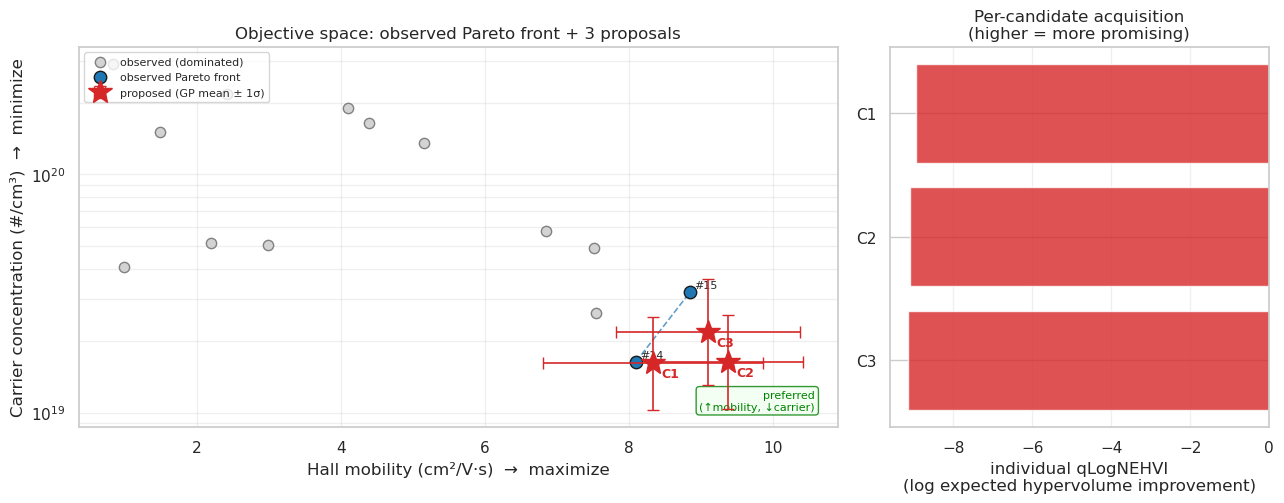

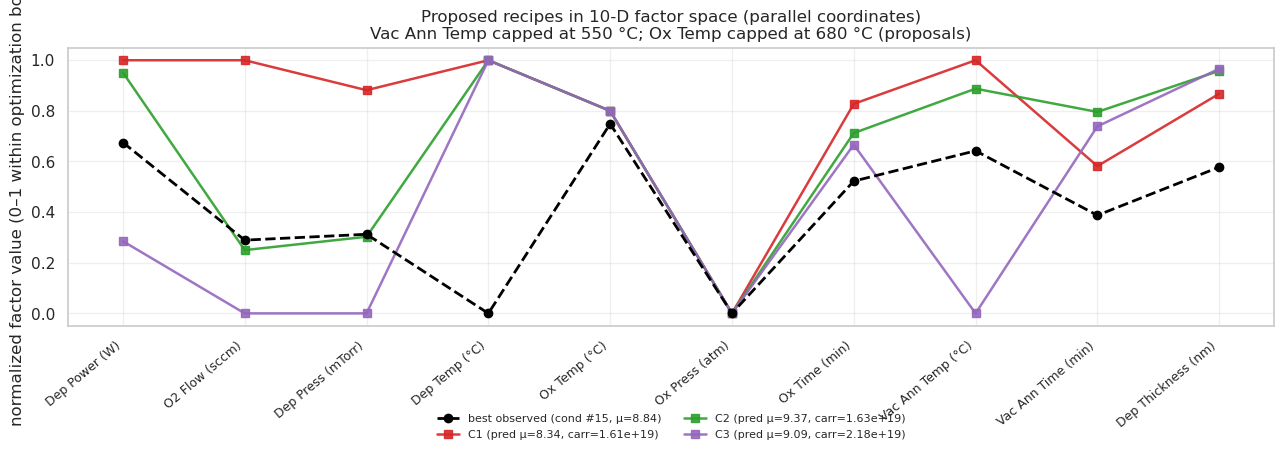

In [169]:
# --- Visualize: (1) objective-space Pareto front with proposals, (2) per-candidate EHVI,
#     (3) parallel-coordinates of the proposed 10-D recipes ---

# (1)+(2): objective plane + acquisition ranking
fig, (axp, axb) = plt.subplots(1, 2, figsize=(13, 5.2), gridspec_kw={'width_ratios': [2, 1]})

obs_mob = bo_cond[RESP].values
obs_carr = bo_cond[CARR].values
pm_mask = pareto_mask.numpy()
axp.scatter(obs_mob[~pm_mask], obs_carr[~pm_mask], c='lightgray', edgecolor='gray',
            s=55, label='observed (dominated)', zorder=2)
axp.scatter(obs_mob[pm_mask], obs_carr[pm_mask], c='#1f77b4', edgecolor='k',
            s=80, label='observed Pareto front', zorder=3)
# connect the Pareto frontier
pf = bo_cond.loc[pm_mask].sort_values(RESP)
axp.plot(pf[RESP], pf[CARR], color='#1f77b4', ls='--', lw=1.2, alpha=0.7, zorder=2)
# annotate Pareto condition IDs
for _, r in pf.iterrows():
    axp.annotate(f"#{int(r['Base_Run_ID'])}", (r[RESP], r[CARR]),
                 fontsize=8, xytext=(3, 3), textcoords='offset points')

# proposals at predicted mean ± 1 sigma
cand_mob = prop['pred_mobility'].values
cand_carr = prop['pred_carrier_cm-3'].values
mob_err = prop['pred_mobility_sd'].values
log_sd = ps[:, 1]  # sd of -log10(carrier) == sd of log10(carrier)
carr_lo = cand_carr - 10 ** (prop['pred_log10_carrier'].values - log_sd)
carr_hi = 10 ** (prop['pred_log10_carrier'].values + log_sd) - cand_carr
axp.errorbar(cand_mob, cand_carr, xerr=mob_err, yerr=[carr_lo, carr_hi],
             fmt='*', ms=18, color='#d62728', ecolor='#d62728', elinewidth=1.2,
             capsize=4, label='proposed (GP mean ± 1σ)', zorder=5)
for i, txt in enumerate(prop['Candidate']):
    axp.annotate(txt, (cand_mob[i], cand_carr[i]), fontsize=9, fontweight='bold',
                 color='#d62728', xytext=(6, -10), textcoords='offset points')
axp.set_yscale('log')
axp.set_xlabel('Hall mobility (cm²/V·s)  →  maximize')
axp.set_ylabel('Carrier concentration (#/cm³)  →  minimize')
axp.set_title('Objective space: observed Pareto front + 3 proposals')
axp.legend(fontsize=8, loc='upper left'); axp.grid(True, which='both', alpha=0.3)
# arrow pointing to the preferred corner
axp.annotate('preferred\n(↑mobility, ↓carrier)', xy=(0.97, 0.04), xycoords='axes fraction',
             ha='right', va='bottom', fontsize=8, color='green',
             bbox=dict(boxstyle='round', fc='honeydew', ec='green', alpha=0.8))

# (2) per-candidate acquisition value
axb.barh(prop['Candidate'][::-1], prop['acq_qLogNEHVI_individual'][::-1], color='#d62728', alpha=0.8)
axb.set_xlabel('individual qLogNEHVI\n(log expected hypervolume improvement)')
axb.set_title('Per-candidate acquisition\n(higher = more promising)')
axb.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'botorch_pareto_candidates.png'), dpi=200, bbox_inches='tight')
plt.show()

# (3) parallel coordinates of the proposed recipes in normalized [0,1] factor space,
#     overlaid on the current best-mobility condition for reference.
cand_unit = candidates.detach().numpy()
best_cond_row = bo_cond.loc[bo_cond[RESP].idxmax()]
best_unit = to_unit(best_cond_row[FACTORS].to_frame().T)[0]

fig, ax = plt.subplots(figsize=(13, 5))
xs = np.arange(len(FACTORS))
ax.plot(xs, best_unit, color='black', lw=2.0, marker='o', ls='--',
        label=f"best observed (cond #{int(best_cond_row['Base_Run_ID'])}, μ={best_cond_row[RESP]:.2f})", zorder=3)
colors = ['#d62728', '#2ca02c', '#9467bd']
for i in range(len(cand_unit)):
    ax.plot(xs, cand_unit[i], color=colors[i % 3], lw=1.8, marker='s', alpha=0.9,
            label=f"{prop['Candidate'].iloc[i]} (pred μ={cand_mob[i]:.2f}, carr={cand_carr[i]:.2e})")
ax.set_xticks(xs); ax.set_xticklabels(FACTORS, rotation=40, ha='right', fontsize=9)
ax.set_ylabel('normalized factor value (0–1 within optimization bounds)')
ax.set_ylim(-0.05, 1.05)
ax.set_title('Proposed recipes in 10-D factor space (parallel coordinates)\n'
             'Vac Ann Temp capped at 550 °C; Ox Temp capped at 680 °C (proposals)')
ax.legend(fontsize=8, loc='upper center', bbox_to_anchor=(0.5, -0.28), ncol=2, frameon=False)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'botorch_candidates_parallel_coords.png'), dpi=200, bbox_inches='tight')
plt.show()

### 8.4  Which factors does the GP think matter? (ARD relevance)

The `SingleTaskGP` fits a **separate lengthscale per factor** (Automatic Relevance
Determination). A *short* lengthscale means the GP posterior changes quickly along that
factor, so the model considers it more influential — i.e. **relevance = 1 / lengthscale**.
Because every input is normalized to `[0, 1]`, those lengthscales live on a common scale and
are directly comparable across the 10 factors. We read them off the *already-fitted* GP for
both objectives (mobility and log10 carrier).

**Caveat:** with only 14 conditions in 10-D and a lengthscale prior, this is a *relevance
ranking*, not a statistical significance test (no p-values). It answers "what is the
surrogate leaning on?" rather than "what is provably significant?". For variance-based
significance, run Sobol indices on the GP posterior instead. Saved to
`botorch_ard_sensitivity.xlsx` / `.png`.

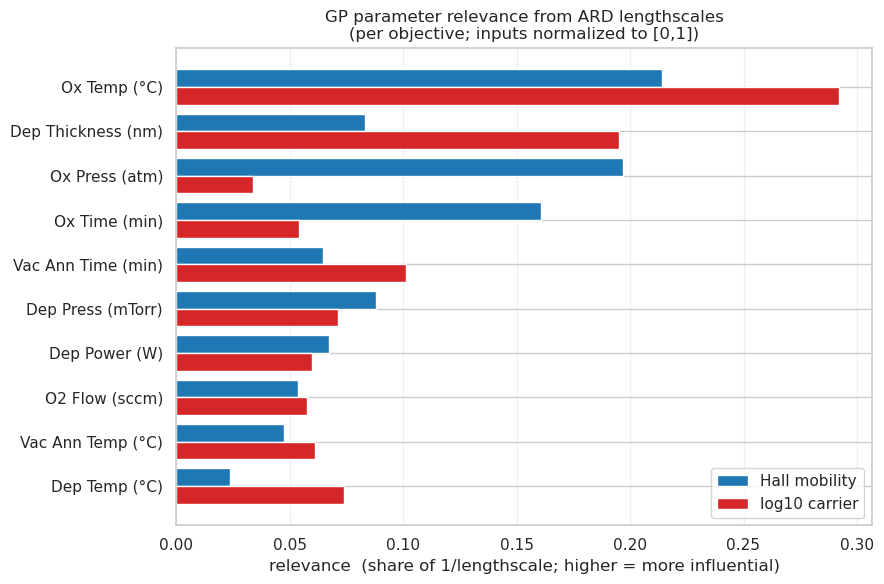

Top-3 factors by combined GP relevance:
Ox Temp (°C)          0.506
Dep Thickness (nm)    0.278
Ox Press (atm)        0.231


,Hall mobility,log10 carrier
Dep Power (W),0.067,0.060
O2 Flow (sccm),0.054,0.058
Dep Press (mTorr),0.088,0.071
Dep Temp (°C),0.024,0.074
Ox Temp (°C),0.214,0.292
Ox Press (atm),0.197,0.034
Ox Time (min),0.161,0.054
Vac Ann Temp (°C),0.047,0.061
Vac Ann Time (min),0.065,0.101
Dep Thickness (nm),0.083,0.195


In [170]:
# --- Parameter relevance from the GP's ARD lengthscales ---
# relevance = 1 / lengthscale, per objective; inputs are normalized to [0,1] so the
# values are comparable across factors. Read as a ranking, not a p-value (14 points, 10-D).
ard = mobo.ard_sensitivity(model, factor_names=FACTORS,
                           output_names=['Hall mobility', 'log10 carrier'],
                           normalize='sum')
ard.round(4).to_excel(os.path.join(OUT_DIR, 'botorch_ard_sensitivity.xlsx'))

order = ard.sum(axis=1).sort_values().index            # least -> most relevant overall
ard_s = ard.loc[order]
y = np.arange(len(ard_s)); h = 0.4
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(y + h/2, ard_s['Hall mobility'].values, height=h, color='#1f77b4', label='Hall mobility')
ax.barh(y - h/2, ard_s['log10 carrier'].values, height=h, color='#d62728', label='log10 carrier')
ax.set_yticks(y); ax.set_yticklabels(ard_s.index)
ax.set_xlabel('relevance  (share of 1/lengthscale; higher = more influential)')
ax.set_title('GP parameter relevance from ARD lengthscales\n(per objective; inputs normalized to [0,1])')
ax.legend(); ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'botorch_ard_sensitivity.png'), dpi=200, bbox_inches='tight')
plt.show()

print('Top-3 factors by combined GP relevance:')
print(ard.sum(axis=1).sort_values(ascending=False).head(3).round(3).to_string())
ard.round(3)

### 8.5  Variance-based importance: Sobol indices (functional ANOVA)

The ARD ranking above is read off the GP's lengthscales; here we instead **decompose the
variance** of each GP-predicted objective into the share attributable to every factor —
i.e. *functional ANOVA*. For each objective we report two Sobol indices per factor:

- **First-order $S_1$** — variance explained by that factor *alone* (its main effect).
- **Total-effect $S_T$** — variance explained by that factor *including every interaction*
  it participates in. The gap $S_T - S_1$ is the factor's interaction contribution, and
  $1 - \sum_i S_1^{(i)}$ is the share of variance carried by interactions overall.

The indices are estimated by **Saltelli Monte-Carlo on the GP posterior mean** (Saltelli-2010
for $S_1$, Jansen-1999 for $S_T$) — the surrogate is the cheap function we probe, so this needs
no new wet-lab runs. We sample over the **same domain the optimizer searched** (Ox Temp capped
at 680 °C; Vac Ann already capped via its encoding), and the two binary factors are evaluated at
their two physical levels. Computed with `mobo.sobol_indices`; saved to
`botorch_sobol_indices.xlsx` / `.png`.

**Caveat:** like the ARD view, this describes *what the surrogate learned* from 14 conditions
in 10-D, not a model-free significance test — read it as a variance-share ranking. Small indices
can dip slightly negative from Monte-Carlo noise (clipped to 0 for the plot).

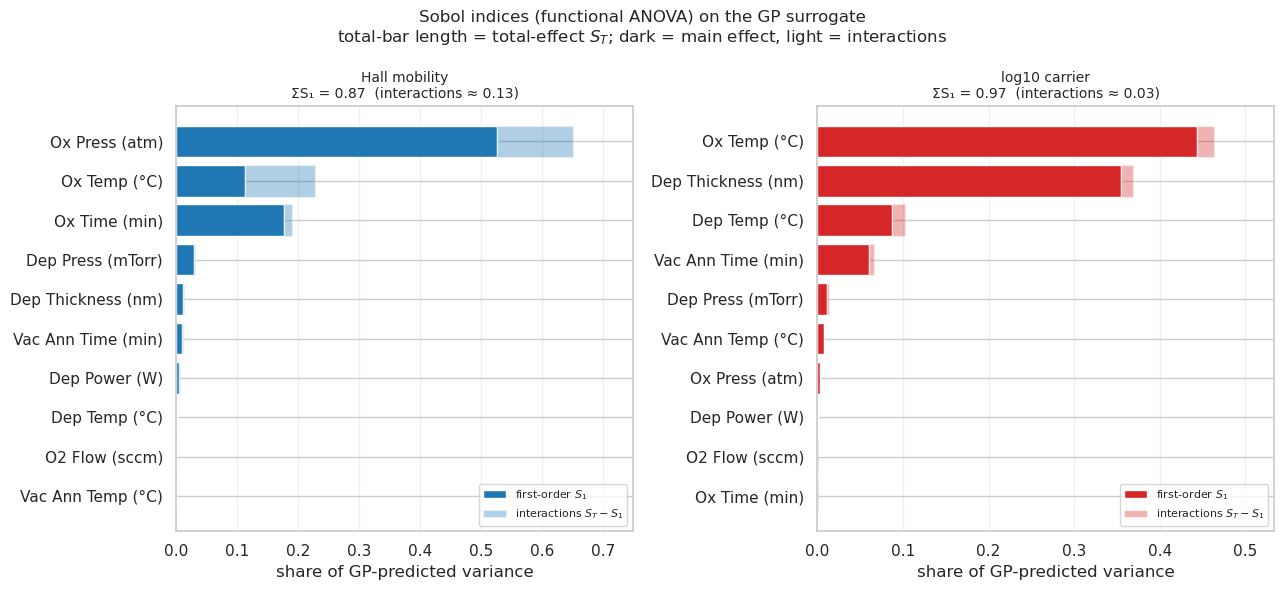

Top-3 factors by total-effect S_T:
  Hall mobility : Ox Press (atm) (0.65), Ox Temp (°C) (0.23), Ox Time (min) (0.19)
  log10 carrier : Ox Temp (°C) (0.46), Dep Thickness (nm) (0.37), Dep Temp (°C) (0.10)


Hall mobility        log10 carrier       
                              S1     ST            S1     ST
Dep Power (W)              0.005  0.007         0.001  0.001
O2 Flow (sccm)             0.000  0.000        -0.000  0.001
Dep Press (mTorr)          0.029  0.031         0.012  0.014
Dep Temp (°C)              0.001  0.001         0.087  0.103
Ox Temp (°C)               0.113  0.228         0.443  0.464
Ox Press (atm)             0.526  0.651         0.003  0.003
Ox Time (min)              0.176  0.189        -0.000  0.001
Vac Ann Temp (°C)          0.000  0.000         0.008  0.008
Vac Ann Time (min)         0.010  0.011         0.061  0.066
Dep Thickness (nm)         0.012  0.013         0.354  0.369

In [171]:
# --- Sobol indices (functional ANOVA) on the fitted GP surrogate ---
# Decompose each objective's GP-predicted variance into first-order (S1) and
# total-effect (ST) shares per factor; ST - S1 is the interaction contribution.
# Sampled over the optimizer's domain (Ox Temp capped at BO_OX_TEMP_MAX; Vac Ann
# capped via its encoding); the two binary factors are held to their two levels.
_lo = np.zeros(len(FACTORS)); _hi = np.ones(len(FACTORS))
_oj = FACTORS.index('Ox Temp (°C)')
_olo, _ohi = BO_CONT_BOUNDS['Ox Temp (°C)']
_hi[_oj] = (BO_OX_TEMP_MAX - _olo) / (_ohi - _olo)          # 680 °C in the (200, 800) encoding
cat_dims = [FACTORS.index('Dep Temp (°C)'), FACTORS.index('Ox Press (atm)')]

sob = mobo.sobol_indices(
    model, factor_names=FACTORS, output_names=['Hall mobility', 'log10 carrier'],
    bounds=np.vstack([_lo, _hi]), cat_dims=cat_dims, n_samples=4096, seed=GLOBAL_SEED)
sob.round(4).to_excel(os.path.join(OUT_DIR, 'botorch_sobol_indices.xlsx'))

# Stacked horizontal bars: dark = main effect S1, light = interactions (ST - S1);
# total bar length = total-effect ST. One panel per objective, sorted by ST.
OBJS = [('Hall mobility', '#1f77b4'), ('log10 carrier', '#d62728')]
fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharey=False)
for ax, (obj, color) in zip(axes, OBJS):
    s1 = sob[(obj, 'S1')].clip(lower=0)
    st = sob[(obj, 'ST')].clip(lower=0)
    o  = st.sort_values().index                     # least -> most important
    s1, st = s1.loc[o], st.loc[o]
    inter = (st - s1).clip(lower=0)                  # interaction share
    y = np.arange(len(o))
    ax.barh(y, s1.values, color=color, label=r'first-order $S_1$')
    ax.barh(y, inter.values, left=s1.values, color=color, alpha=0.35,
            label=r'interactions $S_T - S_1$')
    ax.set_yticks(y); ax.set_yticklabels(o)
    ax.set_xlabel('share of GP-predicted variance')
    ax.set_title(f'{obj}\nΣS₁ = {sob[(obj,"S1")].clip(lower=0).sum():.2f}  '
                 f'(interactions ≈ {max(0, 1 - sob[(obj,"S1")].sum()):.2f})', fontsize=10)
    ax.set_xlim(0, max(0.05, st.max() * 1.15)); ax.grid(True, axis='x', alpha=0.3)
    ax.legend(fontsize=8, loc='lower right')
fig.suptitle('Sobol indices (functional ANOVA) on the GP surrogate\n'
             r'total-bar length = total-effect $S_T$; dark = main effect, light = interactions',
             fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'botorch_sobol_indices.png'), dpi=200, bbox_inches='tight')
plt.show()

print('Top-3 factors by total-effect S_T:')
for obj, _ in OBJS:
    top = sob[(obj, 'ST')].sort_values(ascending=False).head(3)
    print(f'  {obj:14s}: ' + ', '.join(f'{k} ({v:.2f})' for k, v in top.items()))
sob.round(3)

### 8.6  Cross-check with SALib

The same variance decomposition as §8.5, but computed with the **SALib** library
(`SALib.sample.sobol` + `SALib.analyze.sobol`) instead of the in-house
`mobo.sobol_indices`. SALib uses the identical estimators (Saltelli-2010 for $S_1$,
Jansen-1999 for $S_T$), so this is a sanity cross-check: the two should agree to within
Monte-Carlo noise (different quasi-random point sets). We probe the same GP over the same
capped domain, snapping the two binary factors to their physical levels before evaluation.
Saved to `botorch_sobol_indices_salib.xlsx`.

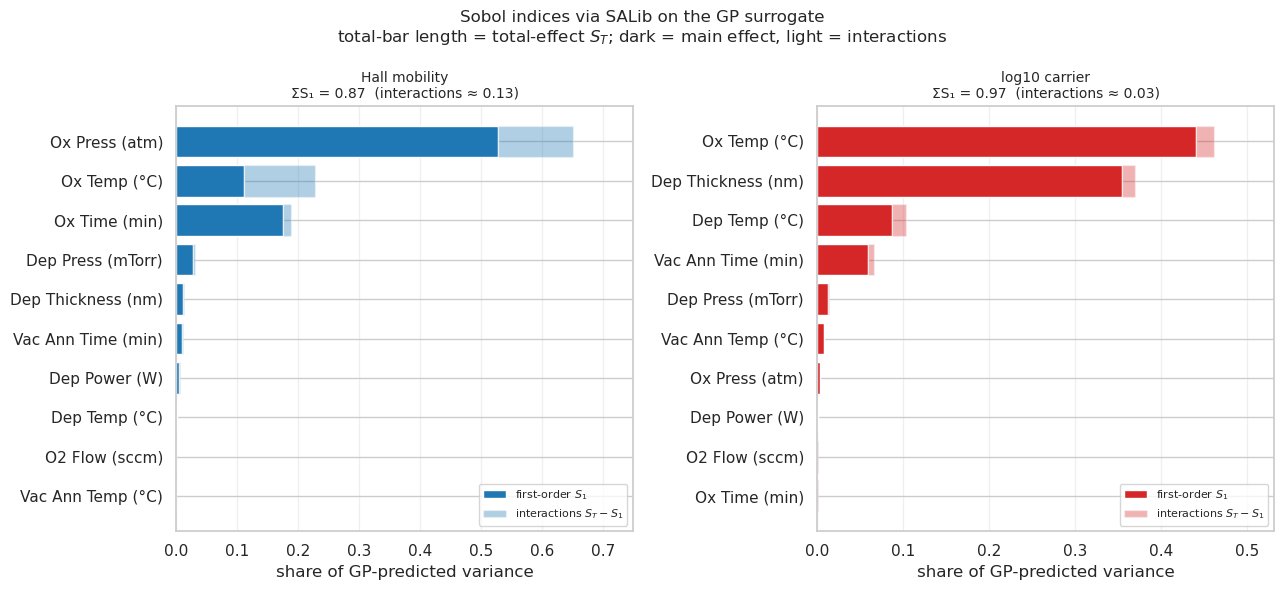

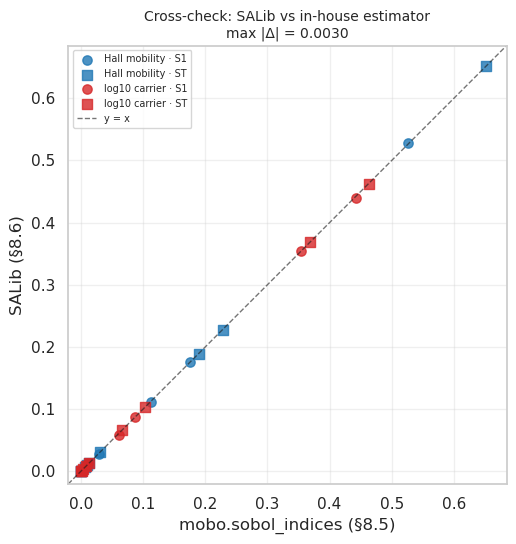

max |SALib - mobo| across all S1/ST = 0.0030  (Monte-Carlo noise only)
Top-3 factors by total-effect S_T (SALib):
  Hall mobility : Ox Press (atm) (0.65), Ox Temp (°C) (0.23), Ox Time (min) (0.19)
  log10 carrier : Ox Temp (°C) (0.46), Dep Thickness (nm) (0.37), Dep Temp (°C) (0.10)


Hall mobility        log10 carrier       
                              S1     ST            S1     ST
Dep Power (W)              0.004  0.007         0.001  0.001
O2 Flow (sccm)             0.000  0.000         0.000  0.001
Dep Press (mTorr)          0.028  0.031         0.013  0.014
Dep Temp (°C)              0.001  0.001         0.087  0.103
Ox Temp (°C)               0.111  0.228         0.440  0.462
Ox Press (atm)             0.528  0.652         0.003  0.003
Ox Time (min)              0.175  0.189        -0.000  0.001
Vac Ann Temp (°C)          0.000  0.000         0.008  0.008
Vac Ann Time (min)         0.010  0.011         0.059  0.066
Dep Thickness (nm)         0.012  0.013         0.355  0.369

In [172]:
# --- Cross-check 8.5 with SALib (variance-based Sobol on the same GP) ---
# Same analysis as 8.5 but via SALib instead of mobo.sobol_indices. We probe the GP
# posterior mean over the optimizer's domain (Ox Temp <= BO_OX_TEMP_MAX); the two binary
# factors are snapped to their {0,1} levels before evaluation, matching 8.5.
from SALib.analyze import sobol as _salib_sobol
try:
    from SALib.sample import sobol as _salib_sample      # SALib >= 1.4
except ImportError:
    from SALib.sample import saltelli as _salib_sample   # older SALib

_d = len(FACTORS)
_cat = [FACTORS.index('Dep Temp (°C)'), FACTORS.index('Ox Press (atm)')]
_oj = FACTORS.index('Ox Temp (°C)')
_olo, _ohi = BO_CONT_BOUNDS['Ox Temp (°C)']
_ox_cap = (BO_OX_TEMP_MAX - _olo) / (_ohi - _olo)          # 680 C in the [0,1] encoding
problem = {'num_vars': _d, 'names': FACTORS,
           'bounds': [[0.0, _ox_cap] if j == _oj else [0.0, 1.0] for j in range(_d)]}

@torch.no_grad()
def _gp_mean(U):
    U = np.asarray(U, dtype=float).copy()
    U[:, _cat] = np.round(U[:, _cat])                      # snap binaries to their two levels
    model.eval()
    return model.posterior(torch.tensor(U, **tkw)).mean.detach().numpy().reshape(-1, 2)

N_SALIB = 4096                                              # power of two; N*(d+2) GP evals
X_salib = _salib_sample.sample(problem, N_SALIB, calc_second_order=False)
Y_salib = _gp_mean(X_salib)

_rows = []
for oi, obj in enumerate(['Hall mobility', 'log10 carrier']):
    Si = _salib_sobol.analyze(problem, Y_salib[:, oi], calc_second_order=False,
                              print_to_console=False)
    _rows.append(pd.DataFrame({(obj, 'S1'): Si['S1'], (obj, 'ST'): Si['ST']}, index=FACTORS))
sob_salib = pd.concat(_rows, axis=1)
sob_salib.columns = pd.MultiIndex.from_tuples(sob_salib.columns)
sob_salib.round(4).to_excel(os.path.join(OUT_DIR, 'botorch_sobol_indices_salib.xlsx'))

# Stacked horizontal bars (same style as 8.5): dark = main effect S1, light = interactions.
OBJS = [('Hall mobility', '#1f77b4'), ('log10 carrier', '#d62728')]
fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharey=False)
for ax, (obj, color) in zip(axes, OBJS):
    s1 = sob_salib[(obj, 'S1')].clip(lower=0)
    st = sob_salib[(obj, 'ST')].clip(lower=0)
    o  = st.sort_values().index
    s1, st = s1.loc[o], st.loc[o]
    inter = (st - s1).clip(lower=0)
    y = np.arange(len(o))
    ax.barh(y, s1.values, color=color, label=r'first-order $S_1$')
    ax.barh(y, inter.values, left=s1.values, color=color, alpha=0.35,
            label=r'interactions $S_T - S_1$')
    ax.set_yticks(y); ax.set_yticklabels(o)
    ax.set_xlabel('share of GP-predicted variance')
    ax.set_title(f'{obj}\nΣS₁ = {sob_salib[(obj,"S1")].clip(lower=0).sum():.2f}  '
                 f'(interactions ≈ {max(0, 1 - sob_salib[(obj,"S1")].sum()):.2f})', fontsize=10)
    ax.set_xlim(0, max(0.05, st.max() * 1.15)); ax.grid(True, axis='x', alpha=0.3)
    ax.legend(fontsize=8, loc='lower right')
fig.suptitle('Sobol indices via SALib on the GP surrogate\n'
             r'total-bar length = total-effect $S_T$; dark = main effect, light = interactions',
             fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'botorch_sobol_indices_salib.png'), dpi=200, bbox_inches='tight')
plt.show()

# Agreement scatter vs the in-house estimator from 8.5: points should sit on y = x.
if 'sob' in globals():
    fig, ax = plt.subplots(figsize=(5.6, 5.6))
    marks = {'S1': 'o', 'ST': 's'}; cols = {'Hall mobility': '#1f77b4', 'log10 carrier': '#d62728'}
    for obj in ['Hall mobility', 'log10 carrier']:
        for idx in ['S1', 'ST']:
            ax.scatter(sob[(obj, idx)].values, sob_salib[(obj, idx)].values,
                       marker=marks[idx], color=cols[obj], alpha=0.8, s=45, label=f'{obj} · {idx}')
    _dmax = (sob_salib - sob).abs().max().max()
    lim = [min(0, sob.values.min(), sob_salib.values.min()) - 0.02,
           max(sob.values.max(), sob_salib.values.max()) * 1.05]
    ax.plot(lim, lim, 'k--', lw=1, alpha=0.6, label='y = x')
    ax.set_xlim(lim); ax.set_ylim(lim); ax.set_aspect('equal')
    ax.set_xlabel('mobo.sobol_indices (§8.5)'); ax.set_ylabel('SALib (§8.6)')
    ax.set_title(f'Cross-check: SALib vs in-house estimator\nmax |Δ| = {_dmax:.4f}', fontsize=10)
    ax.legend(fontsize=7, loc='upper left'); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, 'botorch_sobol_mobo_vs_salib.png'), dpi=200, bbox_inches='tight')
    plt.show()
    print(f'max |SALib - mobo| across all S1/ST = {_dmax:.4f}  (Monte-Carlo noise only)')

print('Top-3 factors by total-effect S_T (SALib):')
for obj in ['Hall mobility', 'log10 carrier']:
    top = sob_salib[(obj, 'ST')].sort_values(ascending=False).head(3)
    print(f'  {obj:14s}: ' + ', '.join(f'{k} ({v:.2f})' for k, v in top.items()))
sob_salib.round(3)

### How to read the optimization results (and its caveats)

- **What "best" means here.** The optimizer trades off two goals at once — *higher* Hall mobility and *lower* carrier concentration. There is rarely a single winner, so it returns a **Pareto set**: recipes that are not beaten on both objectives simultaneously. The 3 proposed candidates are the points qLogNEHVI expects to *expand* that Pareto front the most.
- **`botorch_pareto_candidates.png`** is the honest 2-D summary even though the search is 10-D: observed conditions in the (mobility, carrier) objective plane, the current Pareto frontier highlighted, and the 3 proposals plotted at their GP-predicted means with ±1σ error bars. A proposal sitting toward the lower-right (high mobility, low carrier) and outside the current frontier is the desirable one.
- **`acq_qLogNEHVI_individual`** in the candidate table is each point's expected hypervolume improvement evaluated *on its own* (log scale; higher = more promising). It is the closest scalar to "expected improvement" for ranking the three recipes.
- **`botorch_candidates_parallel_coords.png`** shows the actual 10-factor recipes (normalized 0–1) so you can see how the proposals differ from the current best condition — this is the high-dimensional view that a single 2-D plot cannot give.
- **Caveats.** The GP is trained on only 14 conditions in 10-D, so posterior uncertainty is large (wide error bars are expected and honest). Contact-fail runs were dropped, not modeled, so the optimizer has no explicit failure-avoidance term — we instead constrain the domain (`Vac Ann Temp ≤ 550 °C`) to stay out of the region that produced failures. Re-fitting after these 3 recipes are measured will tighten the surrogate substantially.

## Output files written

All under `repository_dmref/output/experiment02_update_all_sobol/`:

**Data processing & statistics**
- `sobol_v03_completion.xlsx` — plan vs received counts, completion %.
- `factor_means_fail_vs_valid.xlsx` — mean factor settings stratified by contact-fail outcome.
- `condition_summary.xlsx` — per-condition mobility statistics joined with factor settings.
- `condition_consolidated.xlsx` — the 23 unique conditions (replicates collapsed) with factor settings, mean Hall mobility & carrier concentration, and replicate CV % for both responses.
- `anova_per_factor.xlsx` — one-way ANOVA F/p for each factor (median split), **two sheets: Hall mobility and log10 carrier concentration**.
- `anova_between_conditions.xlsx` — between-condition (Base_Run_ID) ANOVA, **two sheets: mobility and log10 carrier**.
- `cv_percentage.xlsx` — coefficient of variation across replicates, **sheets: mobility, carrier, combined**.
- `linear_regression_validation.xlsx` — metrics, coefficients, LOO and LOGO predictions (mobility).
- `linear_regression_validation_carrier.xlsx` — same LOO/LOGO validation for carrier concentration (log10; RMSE/MAE in dex).
- `factor_effects_summary.xlsx` — Pearson r / p per factor for both responses.

**Design extension (Sobol Batch 2)**
- `sobol_batch2_metrics.xlsx` — discrepancy and min-pairwise-distance for Batch 1, Batch 2, cumulative.
- `PdO_DoE_Batch2_capped.xlsx` — the 23 new Batch 2 conditions, the cumulative Batch 1+2 plan, design metrics, config diff.

**Multi-objective Bayesian optimization (§8)**
- `botorch_training_data.xlsx` — the 14 valid condition means used to train the GP, with Pareto-front flag.
- `botorch_proposed_candidates.xlsx` — the **3 proposed recipes** (engineering units + normalized) and the BO config / reference point / hypervolume.
- `botorch_ard_sensitivity.xlsx` / `botorch_ard_sensitivity.png` — per-factor GP relevance (1/ARD-lengthscale) for both objectives.

**Figures (.png)**
- `hall_mobility_overview.png`, `regression_pred_vs_actual.png`, `regression_pred_vs_actual_carrier.png`
- `carrier_concentration_overview.png` — carrier concentration distribution (log10) + per-condition boxplot (log scale).
- `cv_barplot.png`, `cv_barplot_2panel.png` — replicate CV per condition (mobility & carrier; grouped and 2-panel versions).
- `pairplot_factor_vs_response.png`, `per_factor_effects.png`
- `per_factor_effects_by_oxpress.png` — same per-factor grid with replicate dots coloured by Ox Press level (0.02 vs 1.0 atm).
- `batch2_distributions.png`, `batch2_temp_coverage.png` (with infeasible contact-fail × marks), `batch2_temp_coverage_labelled.png` (same plot annotated with each Base_Run_ID), `batch2_all_factor_distributions.png`
- `botorch_pareto_candidates.png` — objective-space Pareto front + 3 proposals + per-candidate acquisition.
- `botorch_candidates_parallel_coords.png` — proposed 10-factor recipes (parallel coordinates).

# Experiment 02 - New system 